In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from linearmodels.panel import PanelOLS
from statsmodels.tsa.stattools import adfuller
import statsmodels.formula.api as smf
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from statsmodels.api import OLS, add_constant

In [2]:
df=pd.read_csv("C:/Users/Hanieh/Desktop/dfs.csv")

In [3]:
df.head()

,Unnamed: 0,country,year,total population,Urban population,working age 15-64,old population 65+,young population 0-14,Per capita carbon dioxide emissions from transport,Annual CO₂ emissions (per capita),Per capita carbon dioxide emissions from buildings,Primary energy consumption per capita (kWh/person),Renewable energy consumption %,GDP per capita,"Manufacturing, value added (% of GDP)","Services, value added (% of GDP)"
0,0,Afghanistan,2010,28284089.0,23.737,49.226055,2.306615,48.467330,0.195870,0.295742,0.017678,1182.8920,15.2,560.621505,12.522577,48.879377
1,1,Albania,2010,2913021.0,52.163,67.383891,10.920055,21.696054,0.764837,1.633426,0.112677,12377.5040,37.0,4094.349686,5.452125,44.025588
2,2,Algeria,2010,36188236.0,67.540,67.648182,4.893586,27.458232,0.876252,3.270490,0.365865,12243.1560,0.3,4912.785855,9.370825,43.602403
3,3,Angola,2010,23294825.0,59.783,52.129928,2.729902,45.140170,0.243831,0.986628,0.155399,3560.0942,53.1,3597.342932,4.541774,41.887026
4,4,Antigua and Barbuda,2010,85320.0,26.238,69.091250,7.153615,23.755135,2.343649,6.440348,0.937460,33104.5400,0.0,15216.309840,2.094549,73.656673


In [4]:
df.drop(columns="Unnamed: 0",inplace=True)

In [5]:
df.isnull().sum()

country                                               0
year                                                  0
total population                                      0
Urban population                                      0
working age 15-64                                     0
old population 65+                                    0
young population 0-14                                 0
Per capita carbon dioxide emissions from transport    0
Annual CO₂ emissions (per capita)                     0
Per capita carbon dioxide emissions from buildings    0
Primary energy consumption per capita (kWh/person)    0
Renewable energy consumption %                        0
GDP per capita                                        0
Manufacturing, value added (% of GDP)                 0
Services, value added (% of GDP)                      0
dtype: int64

In [6]:
df.columns

Index(['country', 'year', 'total population', 'Urban population',
       'working age 15-64', 'old population 65+', 'young population 0-14',
       'Per capita carbon dioxide emissions from transport',
       'Annual CO₂ emissions (per capita)',
       'Per capita carbon dioxide emissions from buildings',
       'Primary energy consumption per capita (kWh/person)',
       'Renewable energy consumption %', 'GDP per capita',
       'Manufacturing, value added (% of GDP)',
       'Services, value added (% of GDP)'],
      dtype='object')

In [7]:
col=['total population', 'Urban population',
       'working age 15-64', 'old population 65+', 'young population 0-14',
       'Per capita carbon dioxide emissions from transport',
       'Annual CO₂ emissions (per capita)',
       'Per capita carbon dioxide emissions from buildings',
       'Primary energy consumption per capita (kWh/person)',
       'Renewable energy consumption %', 'GDP per capita',
       'Manufacturing, value added (% of GDP)',
       'Services, value added (% of GDP)']
df_cor=df[col].corr()
df_cor['Annual CO₂ emissions (per capita)'].sort_values(ascending=False)

Annual CO₂ emissions (per capita)                     1.000000
Primary energy consumption per capita (kWh/person)    0.879598
Per capita carbon dioxide emissions from transport    0.755341
GDP per capita                                        0.633713
working age 15-64                                     0.632216
Urban population                                      0.537124
Per capita carbon dioxide emissions from buildings    0.438274
old population 65+                                    0.238477
Services, value added (% of GDP)                      0.175048
Manufacturing, value added (% of GDP)                 0.027430
total population                                      0.004098
Renewable energy consumption %                       -0.523430
young population 0-14                                -0.530782
Name: Annual CO₂ emissions (per capita), dtype: float64

In [8]:
df[col].corr()

,total population,Urban population,working age 15-64,old population 65+,young population 0-14,Per capita carbon dioxide emissions from transport,Annual CO₂ emissions (per capita),Per capita carbon dioxide emissions from buildings,Primary energy consumption per capita (kWh/person),Renewable energy consumption %,GDP per capita,"Manufacturing, value added (% of GDP)","Services, value added (% of GDP)"
total population,1.000000,-0.023822,0.040619,0.003572,-0.027423,-0.011536,0.004098,0.009253,-0.018810,-0.054196,-0.017937,0.116866,0.049382
Urban population,-0.023822,1.000000,0.546282,0.473691,-0.610764,0.547463,0.537124,0.362820,0.577125,-0.547360,0.584178,0.112347,0.422593
working age 15-64,0.040619,0.546282,1.000000,0.402542,-0.853958,0.532060,0.632216,0.337179,0.616990,-0.706384,0.437162,0.124229,0.355340
old population 65+,0.003572,0.473691,0.402542,1.000000,-0.820075,0.394009,0.238477,0.463415,0.289134,-0.367934,0.541568,0.178454,0.542281
young population 0-14,-0.027423,-0.610764,-0.853958,-0.820075,1.000000,-0.556579,-0.530782,-0.474203,-0.550058,0.650734,-0.581132,-0.179099,-0.530387
Per capita carbon dioxide emissions from transport,-0.011536,0.547463,0.532060,0.394009,-0.556579,1.000000,0.755341,0.595751,0.706512,-0.461459,0.810587,-0.065649,0.405979
Annual CO₂ emissions (per capita),0.004098,0.537124,0.632216,0.238477,-0.530782,0.755341,1.000000,0.438274,0.879598,-0.523430,0.633713,0.027430,0.175048
Per capita carbon dioxide emissions from buildings,0.009253,0.362820,0.337179,0.463415,-0.474203,0.595751,0.438274,1.000000,0.361501,-0.441961,0.562442,0.069604,0.294718
Primary energy consumption per capita (kWh/person),-0.018810,0.577125,0.616990,0.289134,-0.550058,0.706512,0.879598,0.361501,1.000000,-0.404255,0.726084,0.027291,0.243662
Renewable energy consumption %,-0.054196,-0.547360,-0.706384,-0.367934,0.650734,-0.461459,-0.523430,-0.441961,-0.404255,1.000000,-0.337979,-0.036053,-0.410215


<Axes: >

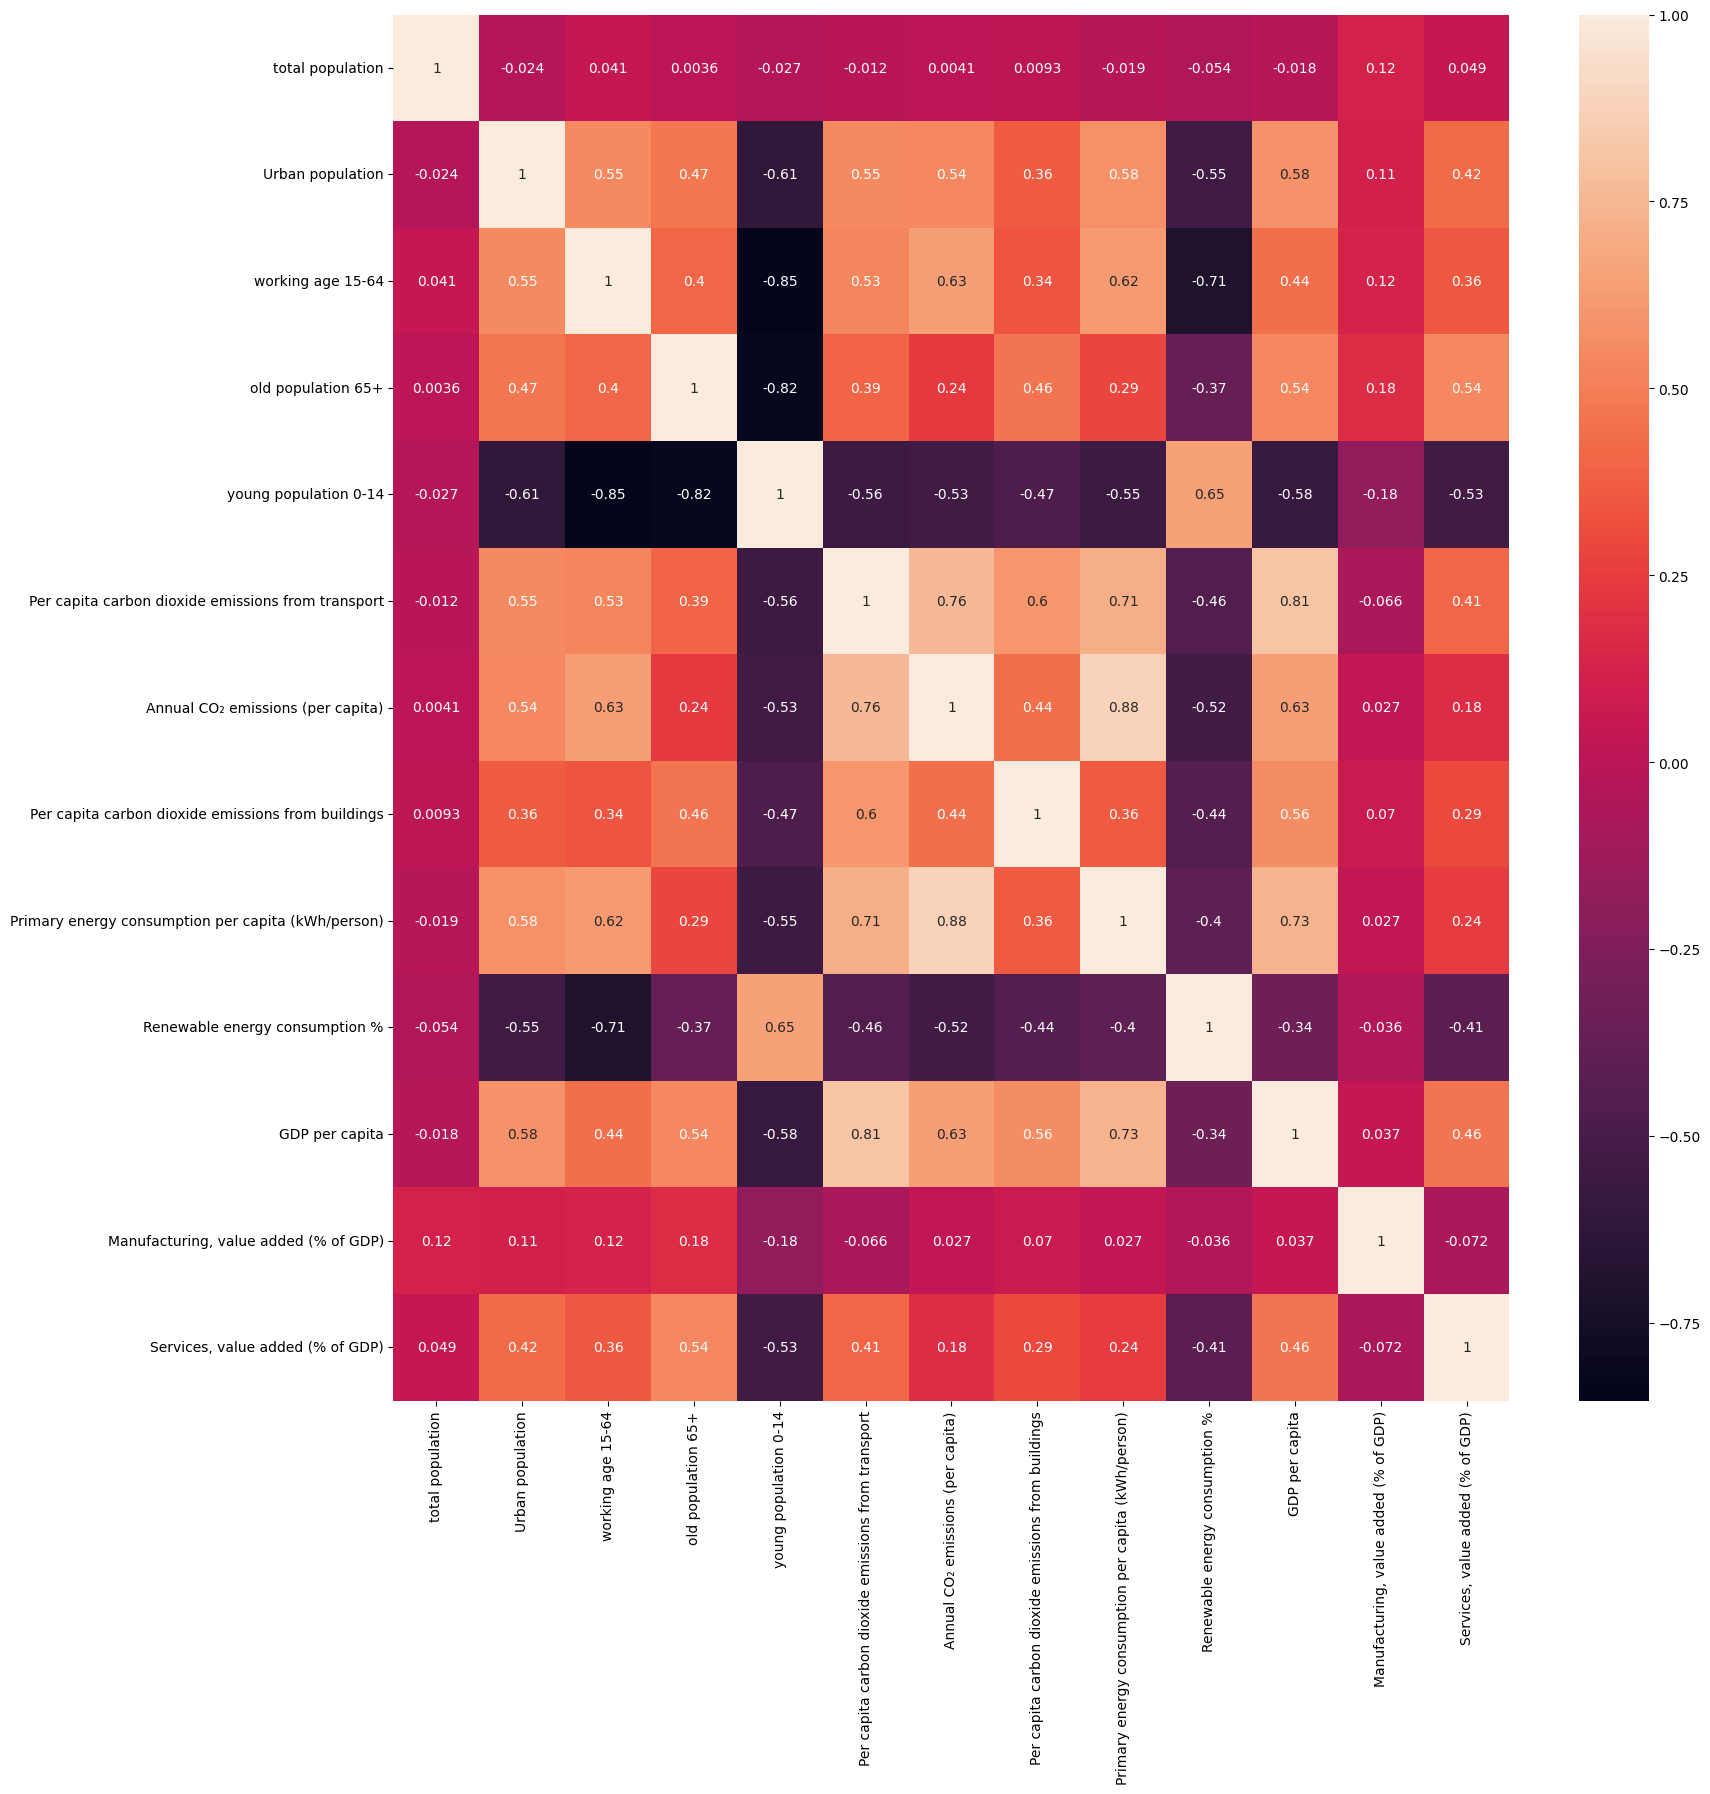

In [9]:
plt.figure(figsize=(18,18))
sns.heatmap(df[col].corr(),annot=True)

In [10]:
print("Number of unique countries:", df["country"].nunique())
print(df.groupby("country")["year"].nunique().value_counts())

Number of unique countries: 165
year
11    164
9       1
Name: count, dtype: int64


In [11]:
df["country"].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Barbados',
       'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia',
       'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Bulgaria',
       'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada',
       'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia',
       'Comoros', 'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba',
       'Cyprus', 'Czechia', 'Denmark', 'Djibouti', 'Dominica',
       'Dominican Republic', 'Ecuador', 'El Salvador',
       'Equatorial Guinea', 'Eritrea', 'Estonia', 'Eswatini', 'Ethiopia',
       'Fiji', 'Finland', 'France', 'Gabon', 'Georgia', 'Germany',
       'Ghana', 'Greece', 'Grenada', 'Guatemala', 'Guinea',
       'Guinea-Bissau', 'Guyana', 'Haiti', 'Honduras', 'Hungary',
       'Iceland', 'India', 'Indonesia', 'Iraq', 'Ireland', 'Israel',
       'Ita

In [12]:
# 'North America', 'World' are not country
df=df[~df["country"].isin(['North America', 'World'])]

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,1791.0,2.015005e+03,3.161302e+00,2010.000000,2.012000e+03,2.015000e+03,2.018000e+03,2.020000e+03
total population,1791.0,4.069023e+07,1.535608e+08,10043.000000,2.636894e+06,9.295784e+06,2.613279e+07,1.411100e+09
Urban population,1791.0,5.770206e+01,2.302446e+01,10.642000,3.982950e+01,5.750500e+01,7.712350e+01,1.000000e+02
working age 15-64,1791.0,6.316274e+01,6.803134e+00,48.127986,5.792674e+01,6.461431e+01,6.747575e+01,8.524949e+01
old population 65+,1791.0,8.347894e+00,6.172996e+00,0.862465,3.369897e+00,5.708475e+00,1.363794e+01,2.891817e+01
young population 0-14,1791.0,2.848937e+01,1.086692e+01,12.174523,1.834404e+01,2.784944e+01,3.823945e+01,4.948234e+01
Per capita carbon dioxide emissions from transport,1791.0,1.090528e+00,1.300195e+00,0.000000,2.004111e-01,7.739902e-01,1.535409e+00,1.340190e+01
Annual CO₂ emissions (per capita),1791.0,4.571273e+00,6.068117e+00,0.025256,6.387479e-01,2.516375e+00,6.137405e+00,4.893290e+01
Per capita carbon dioxide emissions from buildings,1791.0,3.328256e-01,5.270854e-01,0.000000,3.133837e-02,1.215034e-01,3.579969e-01,3.487070e+00
Primary energy consumption per capita (kWh/person),1791.0,2.544870e+04,3.563956e+04,0.000000,2.922710e+03,1.290723e+04,3.044096e+04,2.457238e+05


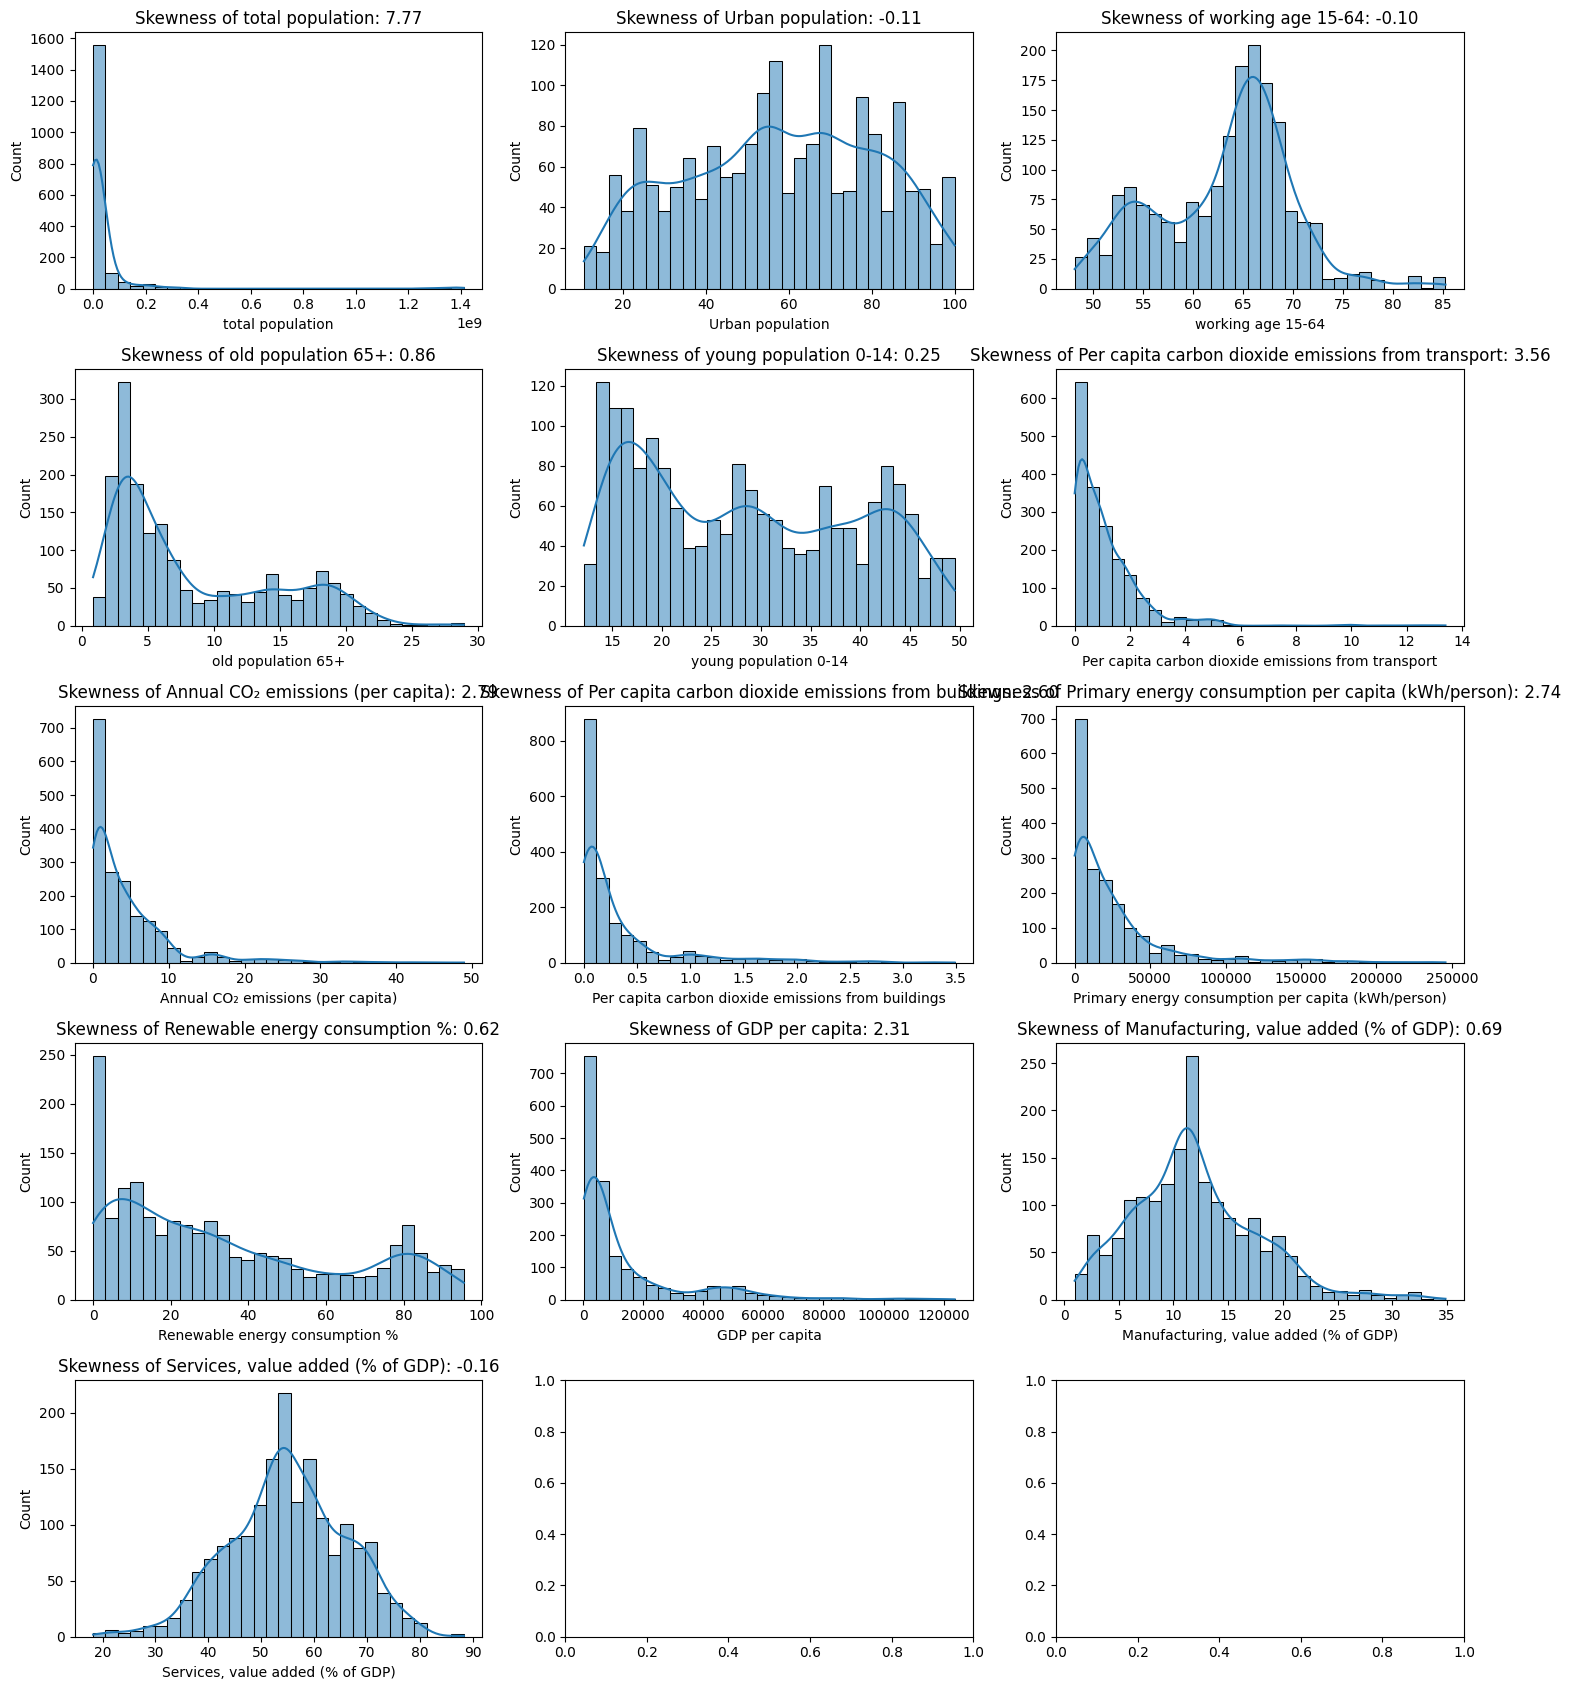

In [14]:
#checking for the skewness of the variables
skewness = df[col].skew()

# Plot distribution of selected variables
fig, axes = plt.subplots(nrows=len(col)//3 + 1, ncols=3, figsize=(15, 4*len(col)//3))
axes = axes.flatten()

for i, col in enumerate(col):
    sns.histplot(df[col].dropna(), bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"Skewness of {col}: {skewness[col]:.2f}")

plt.tight_layout()
plt.show()

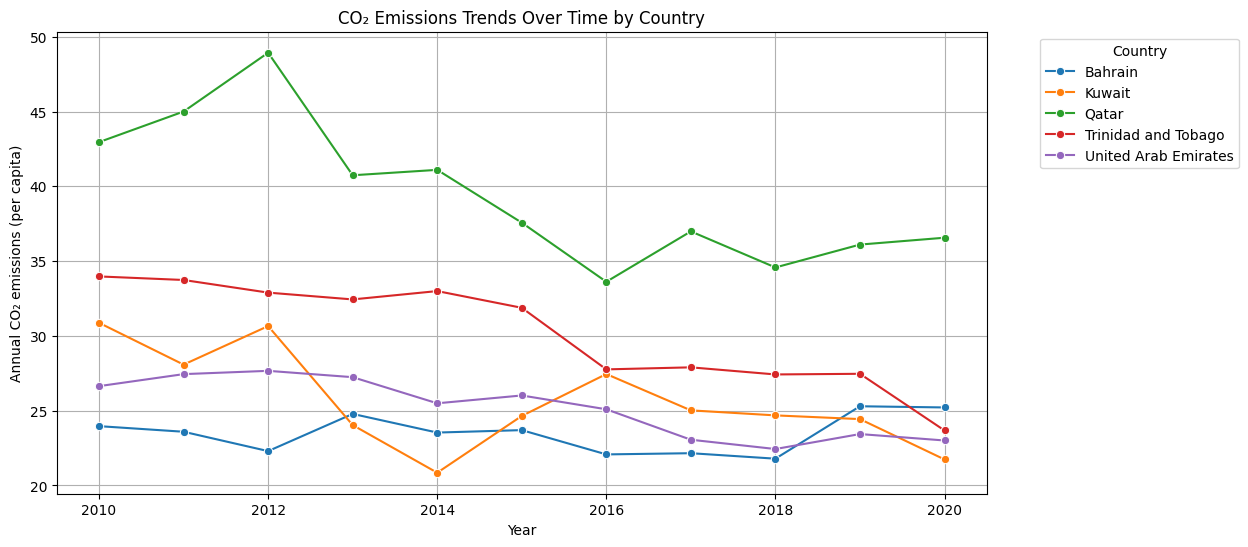

In [15]:
##top 5 countries with the highest co2 emissions
# Standardize column names by stripping spaces
df.columns = df.columns.str.strip()

# Define the CO₂ emissions column
greenhouse_co2_column = "Annual CO₂ emissions (per capita)"  # Ensure this is the correct column

# Select top 5 countries with highest total emissions
top_countries = df.groupby("country")[greenhouse_co2_column].sum().nlargest(5).index


df_filtered = df[df["country"].isin(top_countries)]

# Plot CO₂ emissions trend over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_filtered, x="year", y=greenhouse_co2_column, hue="country", marker="o")


plt.title("CO₂ Emissions Trends Over Time by Country")
plt.xlabel("Year")
plt.ylabel("Annual CO₂ emissions (per capita)")
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

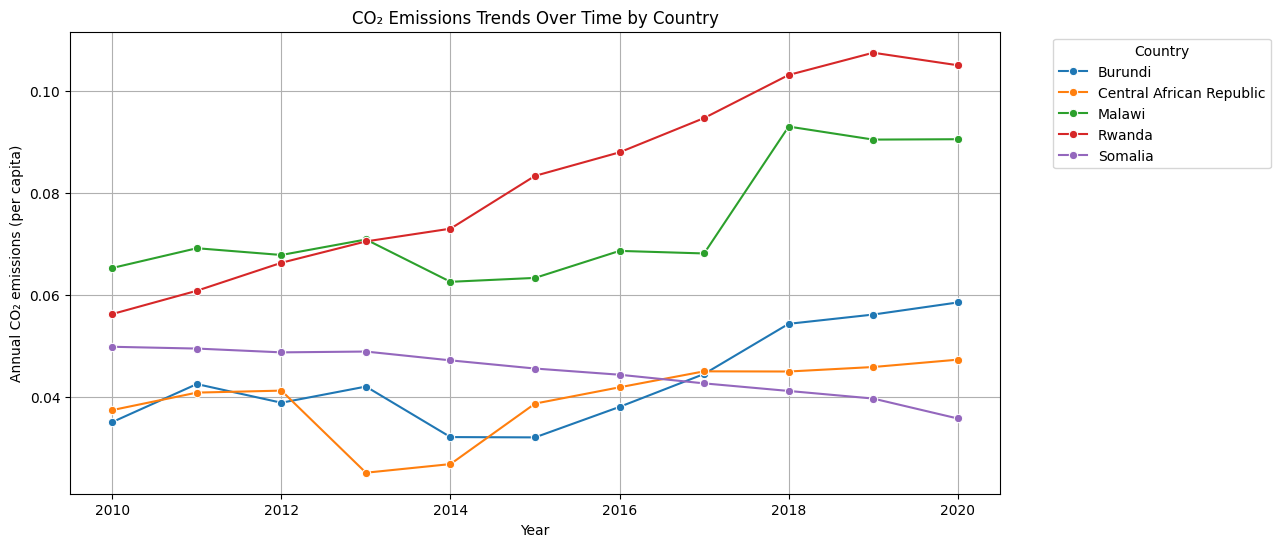

In [16]:
## top 5 countries with lowest co2 emissions
# Standardize column names by stripping spaces
df.columns = df.columns.str.strip()

# Define the CO₂ emissions column
greenhouse_co2_column = "Annual CO₂ emissions (per capita)"  # Ensure this is the correct column

# Select top 10 countries with highest total emissions
top_countries = df.groupby("country")[greenhouse_co2_column].sum().nsmallest(5).index

# Filter dataset for these countries
df_filtered = df[df["country"].isin(top_countries)]

# Plot CO₂ emissions trend over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_filtered, x="year", y=greenhouse_co2_column, hue="country", marker="o")

# Customize the plot
plt.title("CO₂ Emissions Trends Over Time by Country")
plt.xlabel("Year")
plt.ylabel("Annual CO₂ emissions (per capita)")
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

C:\Users\Hanieh\AppData\Local\Temp\ipykernel_7512\1260696371.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("income_level")[["transport_CO2_working_age", "transport_CO2_old", "transport_CO2_young"]].mean()


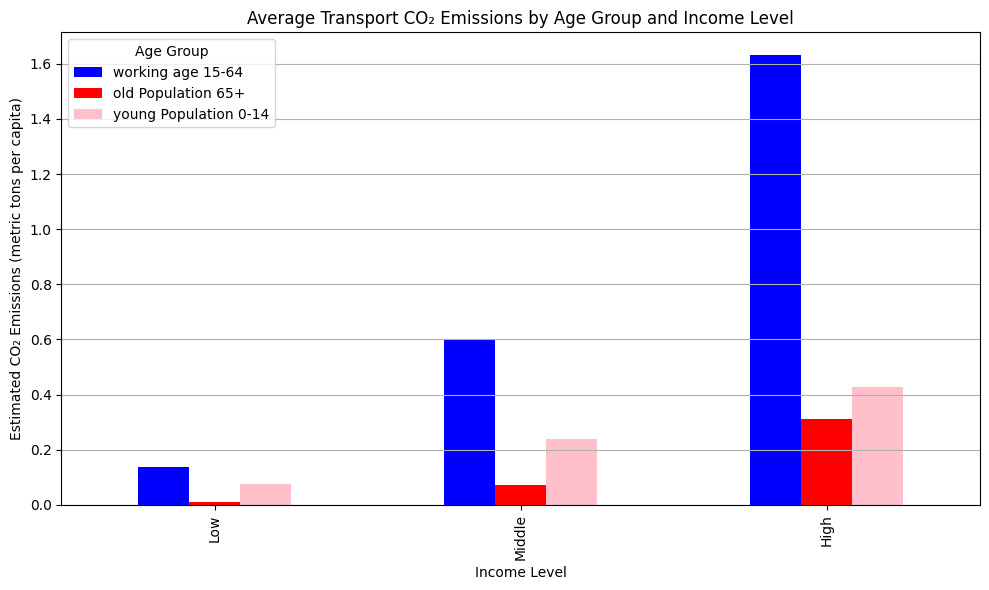

In [17]:
#Transport CO₂ Emissions by Age Group and Income Level

df.columns = df.columns.str.strip()


df["income_level"] = pd.cut(
    df["GDP per capita"],
    bins=[0, 4000, 12000, float("inf")],  # Define the thresholds
    labels=["Low", "Middle", "High"]
)


df["transport_CO2_working_age"] = df["working age 15-64"] * df["Per capita carbon dioxide emissions from transport"] / 100
df["transport_CO2_old"] = df["old population 65+"] * df["Per capita carbon dioxide emissions from transport"] / 100
df["transport_CO2_young"] = df["young population 0-14"] * df["Per capita carbon dioxide emissions from transport"] / 100


grouped = df.groupby("income_level")[["transport_CO2_working_age", "transport_CO2_old", "transport_CO2_young"]].mean()


grouped.plot(kind="bar", figsize=(10, 6), color=["blue", "red", "pink"])
plt.title("Average Transport CO₂ Emissions by Age Group and Income Level")
plt.ylabel("Estimated CO₂ Emissions (metric tons per capita)")
plt.xlabel("Income Level")
plt.legend(["working age 15-64", "old Population 65+", "young Population 0-14"], title="Age Group")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


C:\Users\Hanieh\AppData\Local\Temp\ipykernel_7512\2154012389.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_filtered = df.groupby("Income Group")


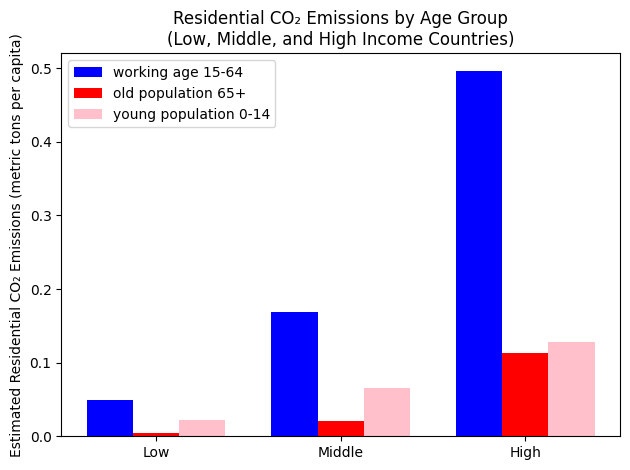

In [18]:
## residential CO₂ Emissions by Age Group and Income Level
df.columns = df.columns.str.strip()

df["Income Group"] = pd.cut(
    df["GDP per capita"],
    bins=[0, 4000, 12000, float("inf")],
    labels=["Low", "Middle", "High"]
)


df["CO2_residential"] = df["Per capita carbon dioxide emissions from buildings"]


grouped_filtered = df.groupby("Income Group")
avg_emissions_filtered = {
    "Income Group": [],
    "working age 15-64": [],
    "old population 65+": [],
    "young population 0-14": []
}

for name, group in grouped_filtered:
    young_emissions = (group["CO2_residential"] * group["working age 15-64"] / 100).mean()
    old_emissions = (group["CO2_residential"] * group["old population 65+"] / 100).mean()
    youth_emissions = (group["CO2_residential"] * group["young population 0-14"] / 100).mean()
    
    avg_emissions_filtered["Income Group"].append(name)
    avg_emissions_filtered["working age 15-64"].append(young_emissions)
    avg_emissions_filtered["old population 65+"].append(old_emissions)
    avg_emissions_filtered["young population 0-14"].append(youth_emissions)

# Convert to DataFrame
emissions_df = pd.DataFrame(avg_emissions_filtered)


labels = emissions_df["Income Group"]
young = emissions_df["working age 15-64"]
old = emissions_df["old population 65+"]
youth = emissions_df["young population 0-14"]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots()
rects1 = ax.bar(x - width, young, width, label='working age 15-64', color='blue')
rects2 = ax.bar(x, old, width, label='old population 65+', color='red')
rects3 = ax.bar(x + width, youth, width, label='young population 0-14', color='pink')

ax.set_ylabel('Estimated Residential CO₂ Emissions (metric tons per capita)')
ax.set_title('Residential CO₂ Emissions by Age Group\n(Low, Middle, and High Income Countries)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.tight_layout()
plt.show()

C:\Users\Hanieh\AppData\Local\Temp\ipykernel_7512\942910488.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_filtered = df.groupby("Income Group")


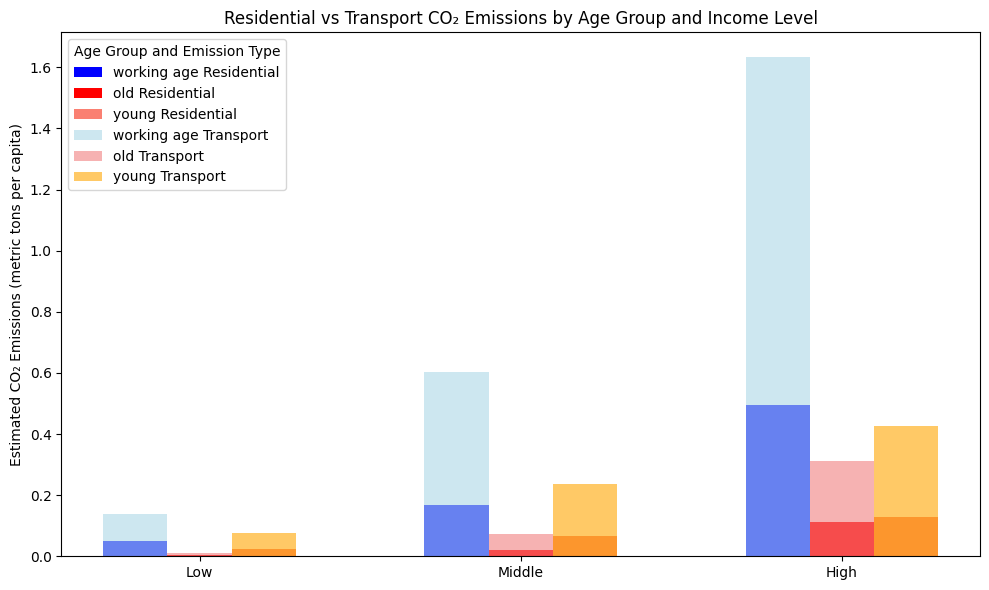

In [19]:
#Comparison of Residential and Transport CO₂ Emissions by Age Group and Income Level

grouped_filtered = df.groupby("Income Group")
avg_emissions_filtered = {
    "Income Group": [],
    "working age Residential": [],
    "old population Residential": [],
    "young population Residential": [],
    "working age Transport": [],
    "old population Transport": [],
    "young population Transport": []
}

for name, group in grouped_filtered:
    young_residential = (group['Per capita carbon dioxide emissions from buildings'] * group["working age 15-64"] / 100).mean()
    old_residential = (group['Per capita carbon dioxide emissions from buildings'] * group["old population 65+"] / 100).mean()
    youth_residential = (group['Per capita carbon dioxide emissions from buildings'] * group["young population 0-14"] / 100).mean()

    young_transport = (group['Per capita carbon dioxide emissions from transport'] * group["working age 15-64"] / 100).mean()
    old_transport = (group['Per capita carbon dioxide emissions from transport'] * group["old population 65+"] / 100).mean()
    youth_transport = (group['Per capita carbon dioxide emissions from transport'] * group["young population 0-14"] / 100).mean()

    avg_emissions_filtered["Income Group"].append(name)
    avg_emissions_filtered["working age Residential"].append(young_residential)
    avg_emissions_filtered["old population Residential"].append(old_residential)
    avg_emissions_filtered["young population Residential"].append(youth_residential)
    avg_emissions_filtered["working age Transport"].append(young_transport)
    avg_emissions_filtered["old population Transport"].append(old_transport)
    avg_emissions_filtered["young population Transport"].append(youth_transport)

# Convert to DataFrame
emissions_df = pd.DataFrame(avg_emissions_filtered)

# Create side-by-side bar chart
labels = emissions_df["Income Group"]
young_residential = emissions_df["working age Residential"]
old_residential = emissions_df["old population Residential"]
youth_residential = emissions_df["young population Residential"]

young_transport = emissions_df["working age Transport"]
old_transport = emissions_df["old population Transport"]
youth_transport = emissions_df["young population Transport"]

# Number of bars for each group
x = np.arange(len(labels))
width = 0.2  # Bar width

fig, ax = plt.subplots(figsize=(10, 6))

# Create bars for each category
rects1 = ax.bar(x - width, young_residential, width, label='working age Residential', color='blue')
rects2 = ax.bar(x, old_residential, width, label='old Residential', color='red')
rects3 = ax.bar(x + width, youth_residential, width, label='young Residential', color='salmon')

rects4 = ax.bar(x - width, young_transport, width, label='working age Transport', color='lightblue', alpha=0.6)
rects5 = ax.bar(x, old_transport, width, label='old Transport', color='lightcoral', alpha=0.6)
rects6 = ax.bar(x + width, youth_transport, width, label='young Transport', color='orange', alpha=0.6)

# labels and titles
ax.set_ylabel('Estimated CO₂ Emissions (metric tons per capita)')
ax.set_title('Residential vs Transport CO₂ Emissions by Age Group and Income Level')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(title="Age Group and Emission Type")

plt.tight_layout()
plt.show()

In [20]:
df[df["GDP per capita"] > 10000]["country"].unique()

array(['Antigua and Barbuda', 'Argentina', 'Australia', 'Austria',
       'Bahrain', 'Barbados', 'Belgium', 'Brazil', 'Canada', 'Chile',
       'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Equatorial Guinea',
       'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary',
       'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan', 'Kuwait',
       'Latvia', 'Libya', 'Lithuania', 'Luxembourg', 'Malta',
       'Netherlands', 'New Zealand', 'Norway', 'Oman', 'Poland',
       'Portugal', 'Qatar', 'Saudi Arabia', 'Seychelles', 'Singapore',
       'Slovenia', 'Spain', 'Sweden', 'Switzerland',
       'Trinidad and Tobago', 'United Arab Emirates', 'United Kingdom',
       'United States', 'Uruguay', 'Gabon', 'Kazakhstan', 'Malaysia',
       'Mexico', 'Costa Rica', 'Panama', 'Mauritius', 'Romania',
       'Maldives', 'Grenada', 'Nauru', 'China', 'Bulgaria'], dtype=object)

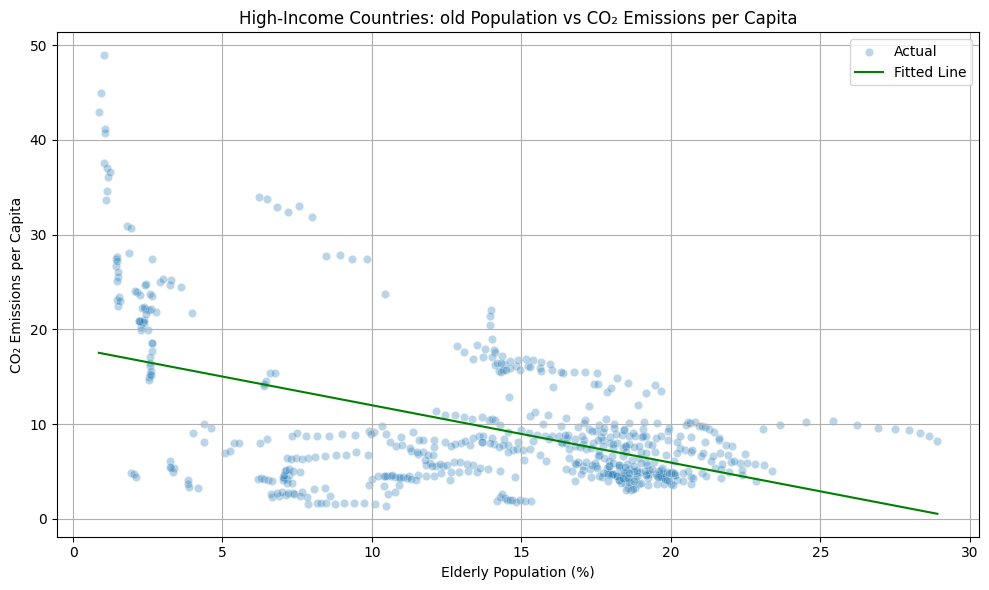

In [21]:
#In high-income countries, as the percentage of elderly population increases,
#CO₂ emissions per capita tend to decrease slightly.
#co2 emission and old population in high-income countries

high_income_df = df[df["GDP per capita"] >=10000].copy()


high_income_df["elderly population"] = pd.to_numeric(high_income_df["old population 65+"], errors='coerce')
high_income_df["Annual CO₂ emissions (per capita)"] = pd.to_numeric(high_income_df["Annual CO₂ emissions (per capita)"], errors='coerce')

# Drop missing values
high_income_df = high_income_df.dropna(subset=["old population 65+", "Annual CO₂ emissions (per capita)"])

# Run linear regression: CO2 ~ elderly population
X = sm.add_constant(high_income_df["old population 65+"])
y = high_income_df["Annual CO₂ emissions (per capita)"]
model = sm.OLS(y, X).fit()
high_income_df["predicted_CO2"] = model.predict(X)


plt.figure(figsize=(10, 6))
sns.scatterplot(data=high_income_df, x="old population 65+", y="Annual CO₂ emissions (per capita)", alpha=0.3, label="Actual")
sns.lineplot(data=high_income_df.sort_values("old population 65+"), x="elderly population", y="predicted_CO2", color='green', label="Fitted Line")
plt.title("High-Income Countries: old Population vs CO₂ Emissions per Capita")
plt.xlabel("Elderly Population (%)")
plt.ylabel("CO₂ Emissions per Capita")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
df[df["GDP per capita"] < 10000]["country"].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Armenia',
       'Azerbaijan', 'Bangladesh', 'Belarus', 'Belize', 'Benin', 'Bhutan',
       'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Bulgaria',
       'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon',
       'Central African Republic', 'Chad', 'China', 'Colombia', 'Comoros',
       'Costa Rica', "Cote d'Ivoire", 'Cuba', 'Djibouti', 'Dominica',
       'Dominican Republic', 'Ecuador', 'El Salvador', 'Eritrea',
       'Eswatini', 'Ethiopia', 'Fiji', 'Gabon', 'Georgia', 'Ghana',
       'Grenada', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana',
       'Haiti', 'Honduras', 'India', 'Indonesia', 'Iraq', 'Jamaica',
       'Jordan', 'Kazakhstan', 'Kenya', 'Kiribati', 'Lebanon', 'Lesotho',
       'Liberia', 'Madagascar', 'Malawi', 'Malaysia', 'Maldives', 'Mali',
       'Mauritania', 'Mauritius', 'Mexico', 'Moldova', 'Mongolia',
       'Montenegro', 'Morocco', 'Mozambique', 'Myanmar', 'Namibia',
       'Nauru', 'Nepal', 'Nicaragua

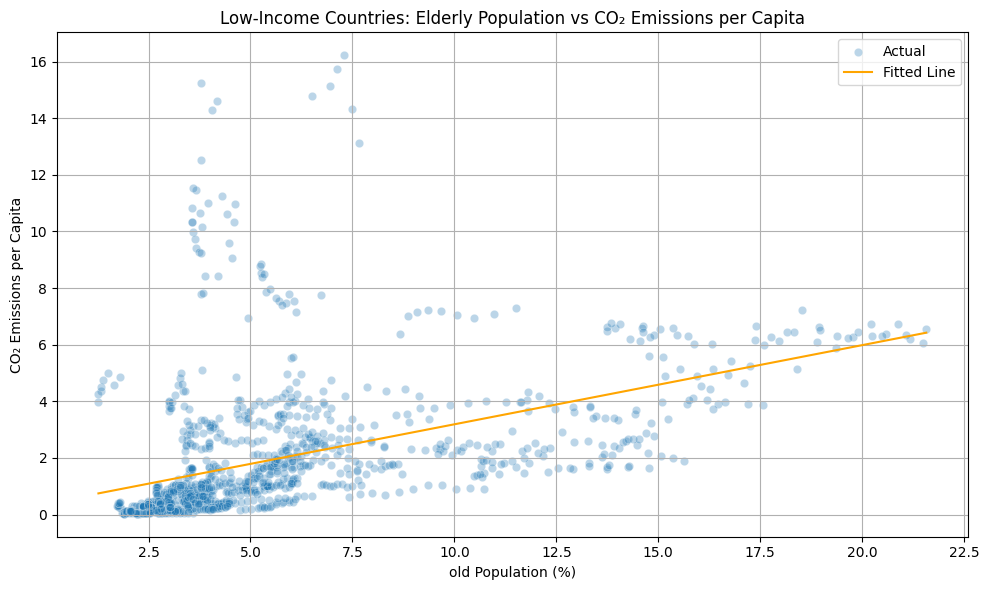

In [23]:
##co2 emission and old population in low-income countries

# Filter low-income countries (GDP per capita < 10,000)
low_income_df = df[df["GDP per capita"] <10000].copy()

# Ensure columns are numeric
low_income_df["old population 65+"] = pd.to_numeric(low_income_df["old population 65+"], errors='coerce')
low_income_df["Annual CO₂ emissions (per capita)"] = pd.to_numeric(low_income_df["Annual CO₂ emissions (per capita)"], errors='coerce')

# Drop rows with missing values
low_income_df = low_income_df.dropna(subset=["old population 65+", "Annual CO₂ emissions (per capita)"])

# Run linear regression: CO₂ ~ elderly population
X = sm.add_constant(low_income_df["old population 65+"])
y = low_income_df["Annual CO₂ emissions (per capita)"]
model = sm.OLS(y, X).fit()
low_income_df["predicted_CO2"] = model.predict(X)

# Plot scatter and regression line
plt.figure(figsize=(10, 6))
sns.scatterplot(data=low_income_df, x="old population 65+", y="Annual CO₂ emissions (per capita)", alpha=0.3, label="Actual")
sns.lineplot(data=low_income_df.sort_values("old population 65+"), x="old population 65+", y="predicted_CO2", color='orange', label="Fitted Line")
plt.title("Low-Income Countries: Elderly Population vs CO₂ Emissions per Capita")
plt.xlabel("old Population (%)")
plt.ylabel("CO₂ Emissions per Capita")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

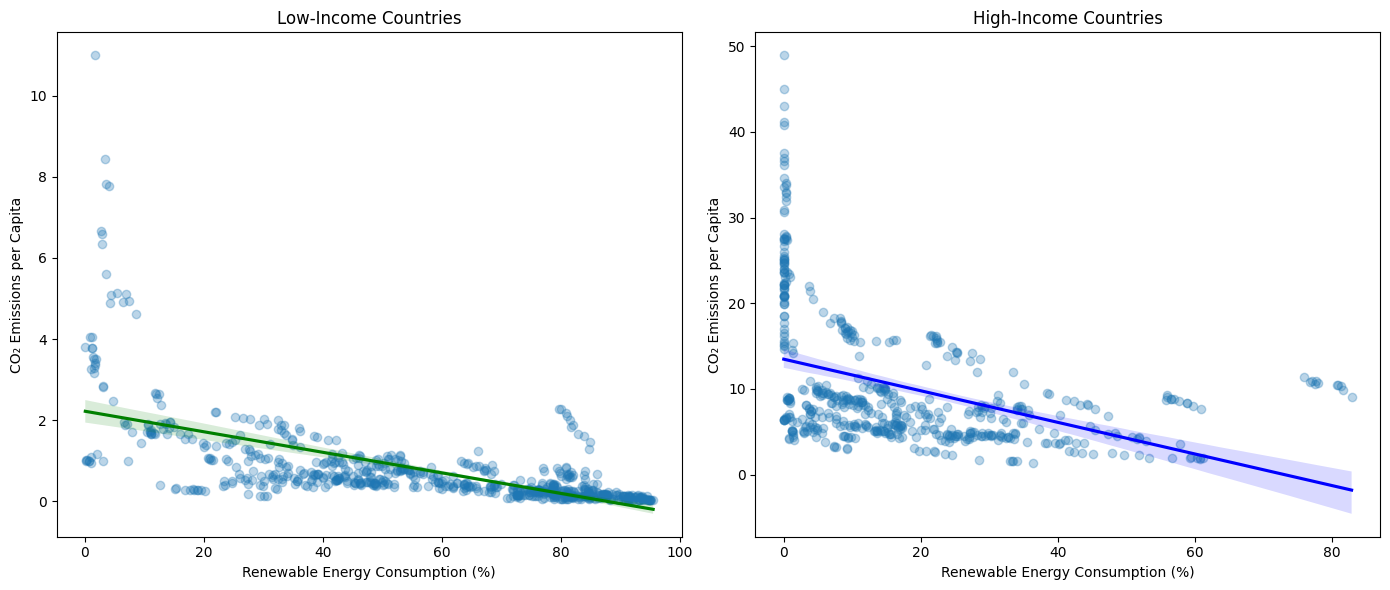

In [24]:
# 3. Renewable Energy Consumption vs CO₂ Emissions in high-income countries and low-income countries

df['income_group'] = pd.cut(df['GDP per capita'],
                            bins=[0, 4000, 12000, float('inf')],
                            labels=['Low', 'Middle', 'High'])

# Filter the data
low_income_df = df[df['income_group'] == 'Low']
high_income_df = df[df['income_group'] == 'High']

# Set up the figure
plt.figure(figsize=(14, 6))

# Plot for Low-Income Countries
plt.subplot(1, 2, 1)
sns.regplot(
    data=low_income_df,
    x='Renewable energy consumption %',
    y='Annual CO₂ emissions (per capita)',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'green'}
)
plt.title('Low-Income Countries')
plt.xlabel('Renewable Energy Consumption (%)')
plt.ylabel('CO₂ Emissions per Capita')

# Plot for High-Income Countries
plt.subplot(1, 2, 2)
sns.regplot(
    data=high_income_df,
    x='Renewable energy consumption %',
    y='Annual CO₂ emissions (per capita)',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'blue'}
)
plt.title('High-Income Countries')
plt.xlabel('Renewable Energy Consumption (%)')
plt.ylabel('CO₂ Emissions per Capita')

plt.tight_layout()
plt.show()

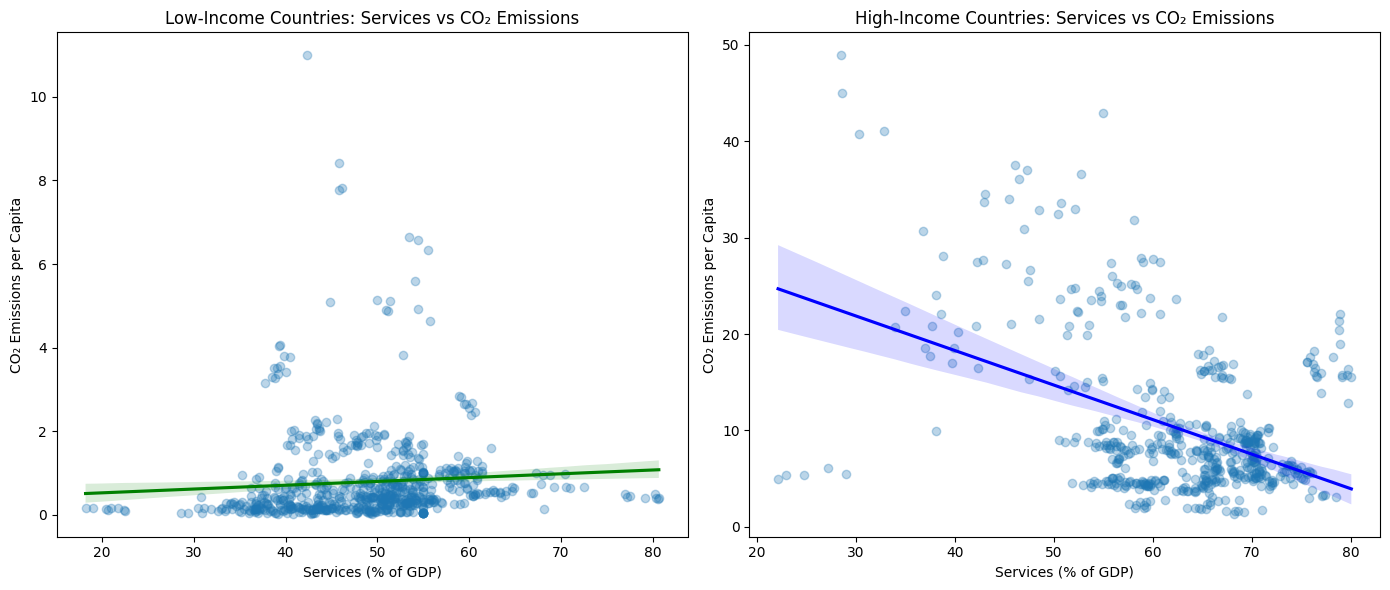

In [25]:
# services vs CO2 emiission in high-income and low-income countries

df.columns = df.columns.str.strip()

# Define income group
df['income_group'] = pd.cut(df['GDP per capita'],
                            bins=[0, 4000, 12000, float('inf')],
                            labels=['Low', 'Middle', 'High'])

# Filter for low and high income
low_income_df = df[df['income_group'] == 'Low']
high_income_df = df[df['income_group'] == 'High']

# Plot
plt.figure(figsize=(14, 6))

# Low-income plot
plt.subplot(1, 2, 1)
sns.regplot(data=low_income_df,
            x='Services, value added (% of GDP)',
            y='Annual CO₂ emissions (per capita)',
            scatter_kws={'alpha': 0.3},
            line_kws={'color': 'green'})
plt.title('Low-Income Countries: Services vs CO₂ Emissions')
plt.xlabel('Services (% of GDP)')
plt.ylabel('CO₂ Emissions per Capita')

# High-income plot
plt.subplot(1, 2, 2)
sns.regplot(data=high_income_df,
            x='Services, value added (% of GDP)',
            y='Annual CO₂ emissions (per capita)',
            scatter_kws={'alpha': 0.3},
            line_kws={'color': 'blue'})
plt.title('High-Income Countries: Services vs CO₂ Emissions')
plt.xlabel('Services (% of GDP)')
plt.ylabel('CO₂ Emissions per Capita')

plt.tight_layout()
plt.show()

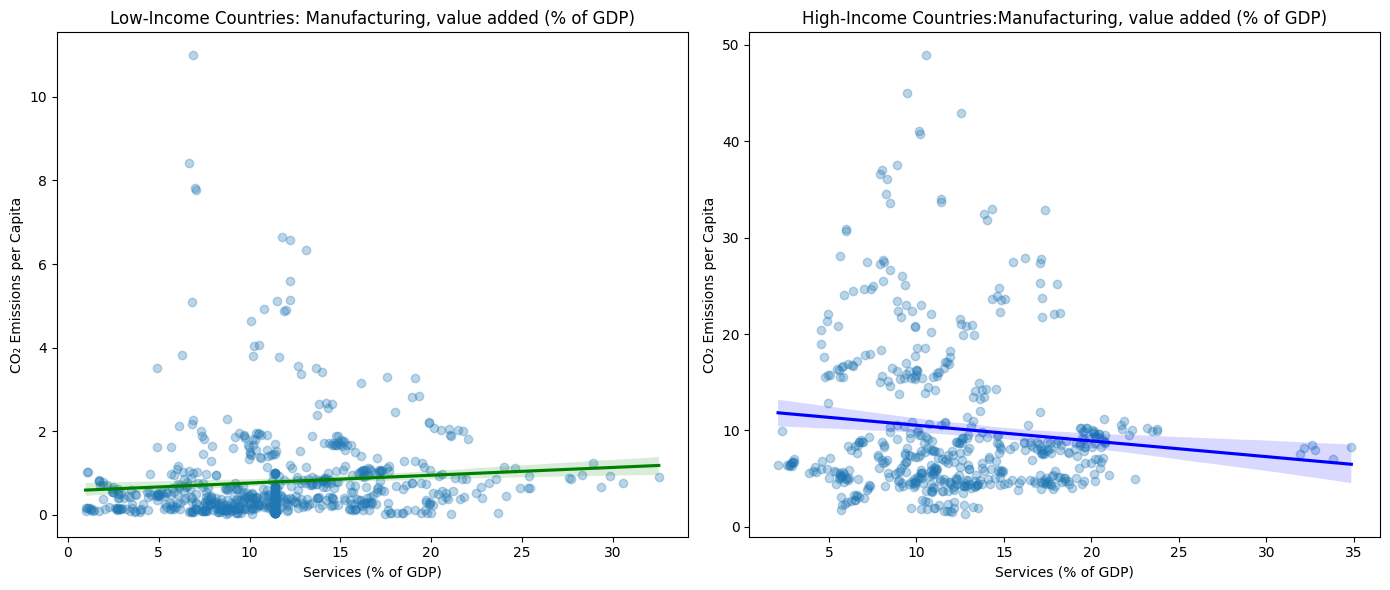

In [26]:
#Per capita carbon dioxide emissions from manufacturing and construction in high-income and low-income countries
df.columns = df.columns.str.strip()

# Define income group
df['income_group'] = pd.cut(df['GDP per capita'],
                            bins=[0, 4000, 12000, float('inf')],
                            labels=['Low', 'Middle', 'High'])

# Filter for low and high income
low_income_df = df[df['income_group'] == 'Low']
high_income_df = df[df['income_group'] == 'High']

# Plot
plt.figure(figsize=(14, 6))

# Low-income plot
plt.subplot(1, 2, 1)
sns.regplot(data=low_income_df,
            x='Manufacturing, value added (% of GDP)',
            y='Annual CO₂ emissions (per capita)',
            scatter_kws={'alpha': 0.3},
            line_kws={'color': 'green'})
plt.title('Low-Income Countries: Manufacturing, value added (% of GDP)')
plt.xlabel('Services (% of GDP)')
plt.ylabel('CO₂ Emissions per Capita')

# High-income plot
plt.subplot(1, 2, 2)
sns.regplot(data=high_income_df,
            x='Manufacturing, value added (% of GDP)',
            y='Annual CO₂ emissions (per capita)',
            scatter_kws={'alpha': 0.3},
            line_kws={'color': 'blue'})
plt.title('High-Income Countries:Manufacturing, value added (% of GDP)')
plt.xlabel('Services (% of GDP)')
plt.ylabel('CO₂ Emissions per Capita')

plt.tight_layout()
plt.show()

In [27]:
df.columns

Index(['country', 'year', 'total population', 'Urban population',
       'working age 15-64', 'old population 65+', 'young population 0-14',
       'Per capita carbon dioxide emissions from transport',
       'Annual CO₂ emissions (per capita)',
       'Per capita carbon dioxide emissions from buildings',
       'Primary energy consumption per capita (kWh/person)',
       'Renewable energy consumption %', 'GDP per capita',
       'Manufacturing, value added (% of GDP)',
       'Services, value added (% of GDP)', 'income_level',
       'transport_CO2_working_age', 'transport_CO2_old', 'transport_CO2_young',
       'Income Group', 'CO2_residential', 'income_group'],
      dtype='object')

In [28]:
# Log-transform the variables

df["ln_GDP"] = np.log(df["GDP per capita"] + 0.01)
df["ln_GDP2"] = df["ln_GDP"] ** 2
df["ln_GDP3"] = df["ln_GDP"] ** 3
df["ln_CO2"] = np.log(df["Annual CO₂ emissions (per capita)"] + 0.01)
df["ln_transport"] = np.log(df["Per capita carbon dioxide emissions from transport"] + 0.01)
df["ln_SVC"] = np.log(df["Services, value added (% of GDP)"] + 0.01)
df["ln_working age"] = np.log(df["working age 15-64"] + 0.01)
df["ln_old"] = np.log(df["old population 65+"] + 0.01)
df["ln_MAF"]=np.log(df["Manufacturing, value added (% of GDP)"]+0.01)
df["ln_buildings"]=np.log(df["Per capita carbon dioxide emissions from buildings"]+0.01)
df["ln_P"]=np.log(df['total population']+0.01)
df["ln_energy"]=np.log(df['Primary energy consumption per capita (kWh/person)']+0.01)
df["ln_renew"]=np.log(df['Renewable energy consumption %']+0.01)
df["ln_young"]=np.log(df["young population 0-14"]+0.01)
df["ln_urban"]=np.log(df["Urban population"]+0.01)

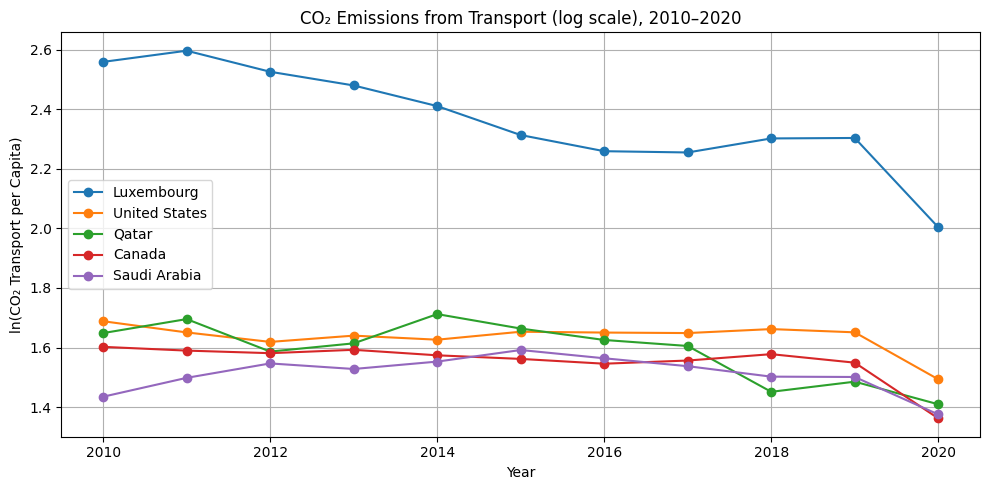

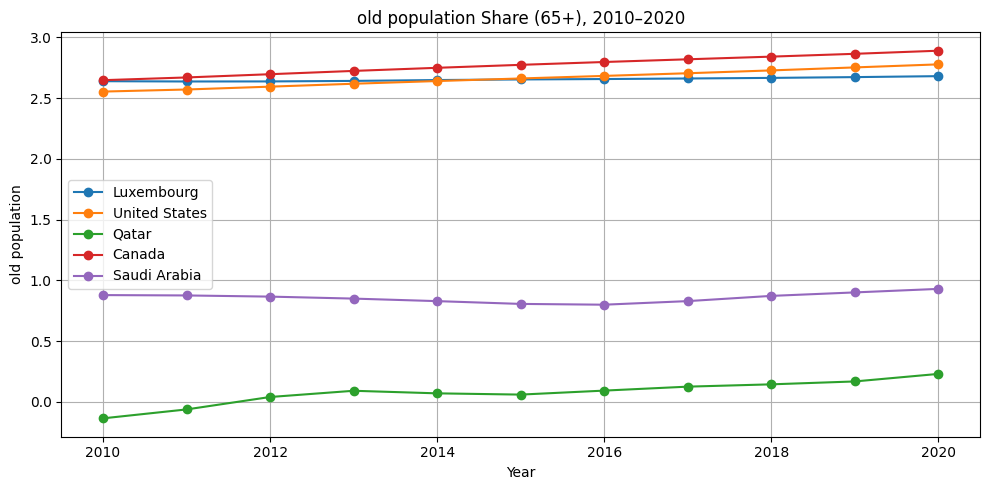

In [29]:
## co2 emission from transport and old poulation share

# Group by country and calculate mean CO2 transport emissions
mean_transport = df.groupby('country')['ln_transport'].mean().sort_values(ascending=False)

# Get top 5 countries with highest average CO2 emissions from transport
top5_countries = mean_transport.head(5).index.tolist()

# Filter dataset for these top 5 countries
df_top5 = df[df['country'].isin(top5_countries)]

# Plot 1: CO2 emissions from transport
plt.figure(figsize=(10, 5))
for country in top5_countries:
    subset = df_top5[df_top5['country'] == country]
    plt.plot(subset['year'], subset['ln_transport'], marker='o', label=country)
plt.title("CO₂ Emissions from Transport (log scale), 2010–2020")
plt.xlabel("Year")
plt.ylabel("ln(CO₂ Transport per Capita)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: Elderly population share
plt.figure(figsize=(10, 5))
for country in top5_countries:
    subset = df_top5[df_top5['country'] == country]
    plt.plot(subset['year'], subset['ln_old'], marker='o', label=country)
plt.title("old population Share (65+), 2010–2020")
plt.xlabel("Year")
plt.ylabel("old population")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Log-Transformed EKC: ln(GDP) vs ln(CO₂ Emissions)')

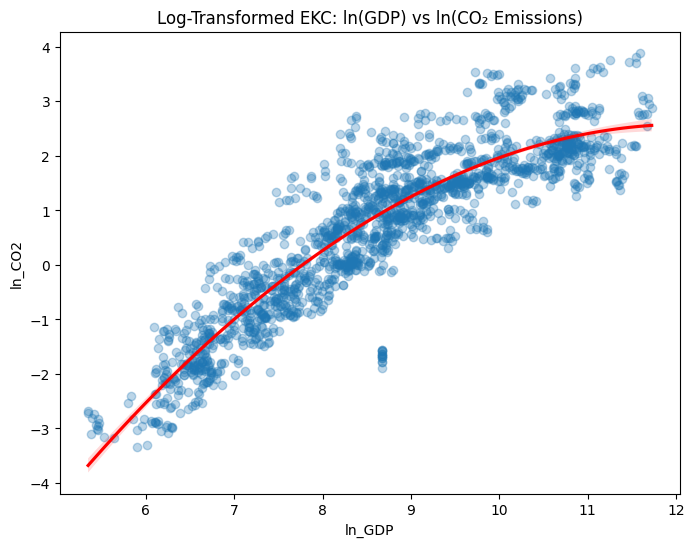

In [30]:
#EKC: GDP per Capita vs CO₂ Emissions
#Shows a clear inverted U-shape, confirming the Environmental Kuznets Curve.

#Emissions increase with GDP at low income levels, then begin to decline at higher income.

# EKC curve: GDP vs CO2 (2nd-degree polynomial fit)
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x='ln_GDP',
    y='ln_CO2',
    order=2,
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'}
)
plt.title("Log-Transformed EKC: ln(GDP) vs ln(CO₂ Emissions)")

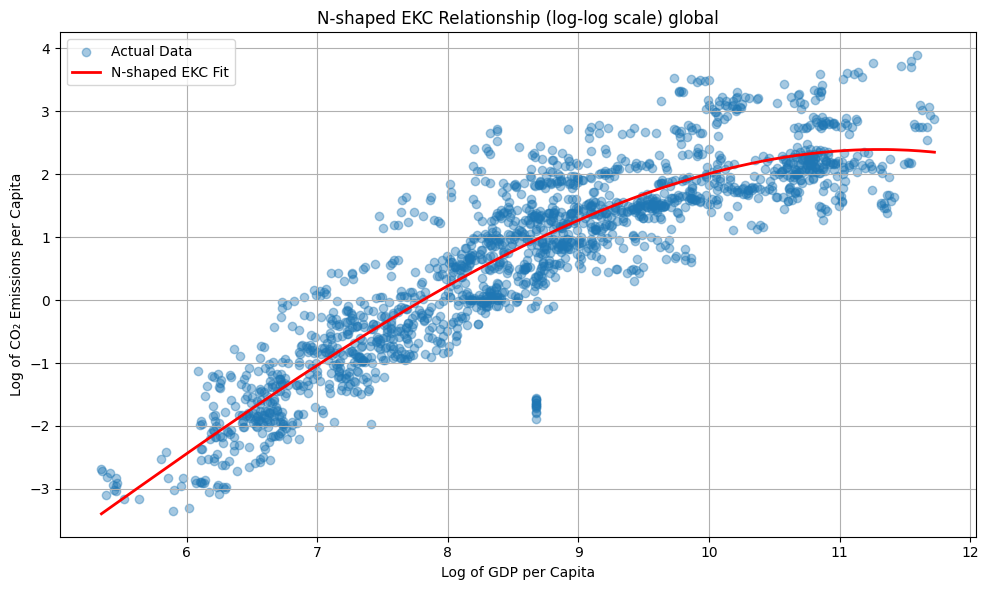

In [31]:
#N-shaped EKC regression analysis 



# Fit cubic regression model
X = df[["ln_GDP", "ln_GDP2", "ln_GDP3"]]
X = sm.add_constant(X)
y = df["ln_CO2"]
model = sm.OLS(y, X).fit()

# Predict and sort for plotting
df["predicted_emissions"] = model.predict(X)
df_sorted = df.sort_values(by="ln_GDP")

# Plot using ln_GDP
plt.figure(figsize=(10, 6))
plt.scatter(df["ln_GDP"], y, alpha=0.4, label="Actual Data")
plt.plot(df_sorted["ln_GDP"], df_sorted["predicted_emissions"], color="red", linewidth=2, label="N-shaped EKC Fit")
plt.xlabel("Log of GDP per Capita")
plt.ylabel("Log of CO₂ Emissions per Capita")
plt.title("N-shaped EKC Relationship (log-log scale) global")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

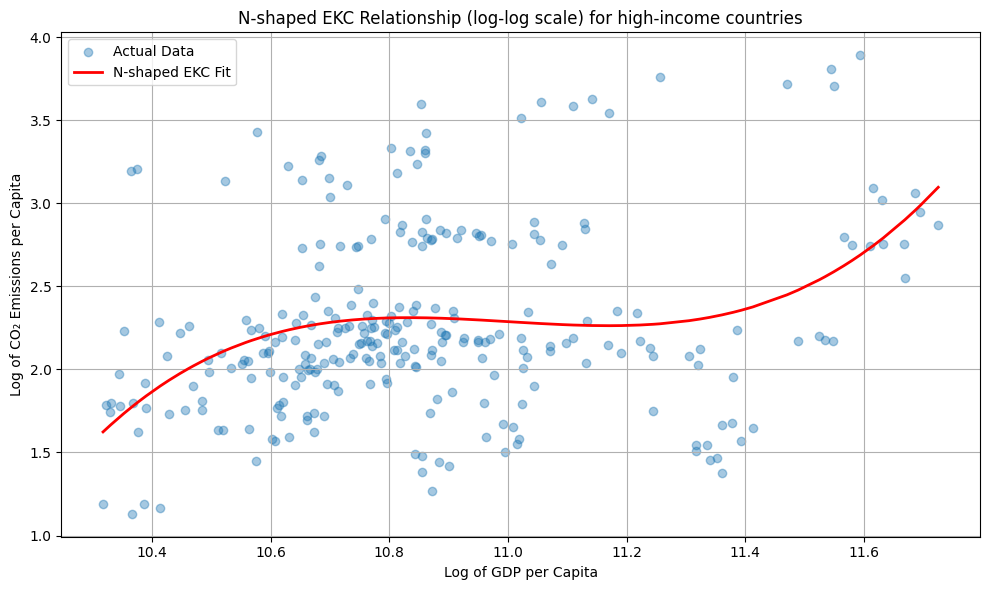

In [32]:
#N-shaped EKC regression analysis for high-income countries

high_income_df = df[df["GDP per capita"] >=30000].copy()




# Fit cubic regression model
X = high_income_df[["ln_GDP", "ln_GDP2", "ln_GDP3"]]
X = sm.add_constant(X)
y = high_income_df["ln_CO2"]
model = sm.OLS(y, X).fit()

# Predict and sort for plotting
high_income_df["predicted_emissions"] = model.predict(X)
high_income_df_sorted = high_income_df.sort_values(by="ln_GDP")

# Plot using ln_GDP
plt.figure(figsize=(10, 6))
plt.scatter(high_income_df["ln_GDP"], y, alpha=0.4, label="Actual Data")
plt.plot(high_income_df_sorted["ln_GDP"], high_income_df_sorted["predicted_emissions"], color="red", linewidth=2, 
         label="N-shaped EKC Fit")
plt.xlabel("Log of GDP per Capita")
plt.ylabel("Log of CO₂ Emissions per Capita")
plt.title("N-shaped EKC Relationship (log-log scale) for high-income countries")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

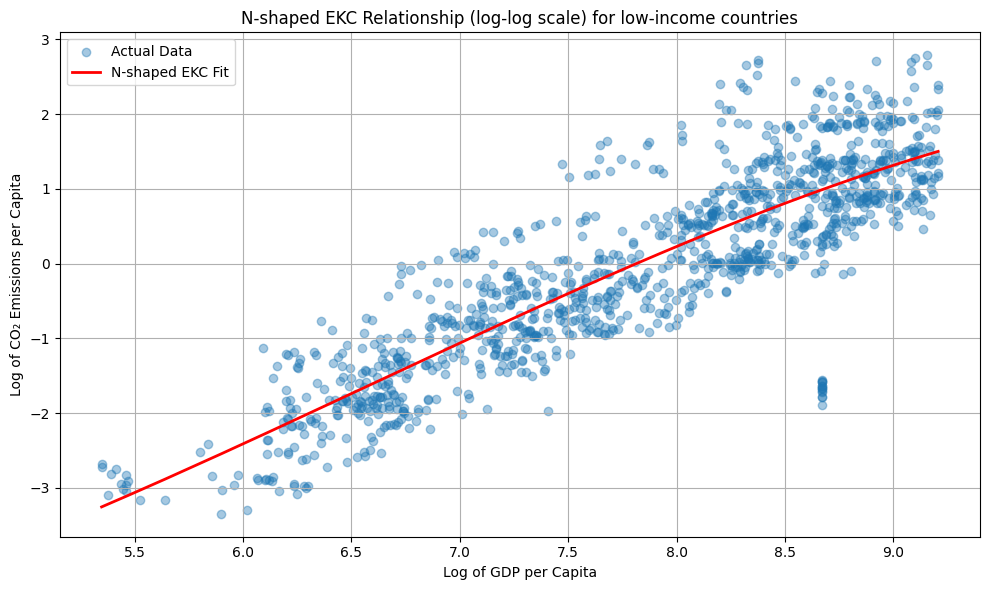

In [33]:
#N-shaped EKC regression analysis for low-income countries

low_income_df =  df[(df["GDP per capita"] <10000)].copy()




# Fit cubic regression model
X = low_income_df[["ln_GDP", "ln_GDP2", "ln_GDP3"]]
X = sm.add_constant(X)
y = low_income_df["ln_CO2"]
model = sm.OLS(y, X).fit()

# Predict and sort for plotting
low_income_df["predicted_emissions"] = model.predict(X)
low_income_df_sorted = low_income_df.sort_values(by="ln_GDP")

# Plot using ln_GDP
plt.figure(figsize=(10, 6))
plt.scatter(low_income_df["ln_GDP"], y, alpha=0.4, label="Actual Data")
plt.plot(low_income_df_sorted["ln_GDP"], low_income_df_sorted["predicted_emissions"], color="red", linewidth=2, 
         label="N-shaped EKC Fit")
plt.xlabel("Log of GDP per Capita")
plt.ylabel("Log of CO₂ Emissions per Capita")
plt.title("N-shaped EKC Relationship (log-log scale) for low-income countries")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:

# Set MultiIndex (important!)
df = df.set_index(['country', 'year'])

# Define dependent and independent variables
y = df["ln_CO2"]

X = df[["ln_GDP", "ln_GDP2", "ln_GDP3", "ln_working age", "ln_young", "ln_old",
        "ln_transport",  "ln_SVC", 'ln_MAF',
       'ln_buildings',"ln_energy","ln_renew"
]]
X = sm.add_constant(X)

# Run PanelOLS (FMOLS-style model with entity effects)
model = PanelOLS(y, X, entity_effects=True)
results = model.fit(cov_type="kernel")

# Show the results
print(results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                 ln_CO2   R-squared:                        0.5501
Estimator:                   PanelOLS   R-squared (Between):              0.7885
No. Observations:                1791   R-squared (Within):               0.5501
Date:                Fri, Apr 11 2025   R-squared (Overall):              0.7859
Time:                        15:34:08   Log-likelihood                    1733.9
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      164.67
Entities:                         163   P-value                           0.0000
Avg Obs:                       10.988   Distribution:                 F(12,1616)
Min Obs:                       9.0000                                           
Max Obs:                       11.000   F-statistic (robust):          2.871e+10
                            

In [36]:
#OLS for high-income countries

high_income_df =  df[(df["GDP per capita"] >30000)].copy()



# Define dependent and independent variables
y = high_income_df["ln_CO2"]
X = high_income_df[["ln_GDP", "ln_GDP2", "ln_GDP3",  "ln_working age", "ln_young", "ln_old",
        "ln_transport",  "ln_SVC", 'ln_MAF',
       'ln_buildings',"ln_energy","ln_renew"]]
X = sm.add_constant(X)

# Run PanelOLS (FMOLS-style model with entity effects)
model = PanelOLS(y, X, entity_effects=True)
results = model.fit(cov_type="kernel")  # kernel handles autocorrelation

# Show the results
print(results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                 ln_CO2   R-squared:                        0.7570
Estimator:                   PanelOLS   R-squared (Between):              0.5840
No. Observations:                 280   R-squared (Within):               0.7570
Date:                Fri, Apr 11 2025   R-squared (Overall):              0.6049
Time:                        15:34:26   Log-likelihood                    456.72
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      62.296
Entities:                          28   P-value                           0.0000
Avg Obs:                      10.0000   Distribution:                  F(12,240)
Min Obs:                       2.0000                                           
Max Obs:                       11.000   F-statistic (robust):          3.726e+04
                            

In [37]:
#OLS for low-income countries

low_income_df =  df[(df["GDP per capita"] <30000)].copy()


# Define dependent and independent variables
y = low_income_df["ln_CO2"]
X = low_income_df[["ln_GDP", "ln_GDP2", "ln_GDP3",  "ln_working age", "ln_young", "ln_old",
        "ln_transport",  "ln_SVC", 'ln_MAF',
       'ln_buildings',"ln_energy","ln_renew"]]
X = sm.add_constant(X)

# Run PanelOLS (FMOLS-style model with entity effects)
model = PanelOLS(y, X, entity_effects=True)
results = model.fit(cov_type="kernel")  # kernel handles autocorrelation

# Show the results
print(results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                 ln_CO2   R-squared:                        0.5469
Estimator:                   PanelOLS   R-squared (Between):              0.7391
No. Observations:                1511   R-squared (Within):               0.5469
Date:                Fri, Apr 11 2025   R-squared (Overall):              0.7315
Time:                        15:34:35   Log-likelihood                    1404.8
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      136.82
Entities:                         139   P-value                           0.0000
Avg Obs:                       10.871   Distribution:                 F(12,1360)
Min Obs:                       4.0000                                           
Max Obs:                       11.000   F-statistic (robust):         -5.959e+10
                            

In [38]:
# find the work age population

df['YouthDep'] = df['young population 0-14'] / df['working age 15-64']
df['OldDep'] = df['old population 65+'] / df['working age 15-64']

In [39]:
df['lnYouthDep'] = np.log(df['YouthDep'] + 0.01)
df['lnOldDep'] = np.log(df['OldDep'] + 0.01)

In [40]:
df.columns

Index(['total population', 'Urban population', 'working age 15-64',
       'old population 65+', 'young population 0-14',
       'Per capita carbon dioxide emissions from transport',
       'Annual CO₂ emissions (per capita)',
       'Per capita carbon dioxide emissions from buildings',
       'Primary energy consumption per capita (kWh/person)',
       'Renewable energy consumption %', 'GDP per capita',
       'Manufacturing, value added (% of GDP)',
       'Services, value added (% of GDP)', 'income_level',
       'transport_CO2_working_age', 'transport_CO2_old', 'transport_CO2_young',
       'Income Group', 'CO2_residential', 'income_group', 'ln_GDP', 'ln_GDP2',
       'ln_GDP3', 'ln_CO2', 'ln_transport', 'ln_SVC', 'ln_working age',
       'ln_old', 'ln_MAF', 'ln_buildings', 'ln_P', 'ln_energy', 'ln_renew',
       'ln_young', 'ln_urban', 'predicted_emissions', 'YouthDep', 'OldDep',
       'lnYouthDep', 'lnOldDep'],
      dtype='object')

In [41]:
#descriptive statistics
col=['ln_CO2','ln_GDP', 'ln_energy','ln_renew','ln_P', "ln_SVC", 'ln_MAF',
       "ln_old","ln_young",'lnYouthDep',
       'lnOldDep']
# Calculate descriptive statistics for all variables
descriptive_stats = df[col].describe().transpose()
descriptive_stats['Skewness'] = df[col].skew()
descriptive_stats['Kurtosis'] = df[col].kurt()

# Display the descriptive statistics
print(descriptive_stats[['mean', 'std', 'Skewness', 'Kurtosis', 'count']])

                 mean       std  Skewness   Kurtosis   count
ln_CO2       0.655588  1.506451 -0.429914  -0.573371  1791.0
ln_GDP       8.646631  1.419496  0.040226  -0.806392  1791.0
ln_energy    9.126022  1.905334 -2.451578  14.728802  1791.0
ln_renew     2.733482  1.919876 -2.069871   4.659089  1791.0
ln_P        15.770307  1.983467 -0.494550   0.877514  1791.0
ln_SVC       3.986314  0.215636 -0.918758   1.760218  1791.0
ln_MAF       2.345987  0.565283 -1.048931   1.566132  1791.0
ln_old       1.845177  0.755953  0.120209  -1.156619  1791.0
ln_young     3.272566  0.400434 -0.141712  -1.322283  1791.0
lnYouthDep  -0.841283  0.481158  0.104312  -1.277395  1791.0
lnOldDep    -2.180748  0.637661  0.243346  -0.921614  1791.0


In [42]:
#Panel Unit Root Tests


# Set panel index
#df_panel = df.set_index(['country', 'year'])

# Variables to test
variables = ['ln_CO2','ln_GDP', 'ln_energy','ln_renew','ln_P', "ln_SVC", 'ln_MAF',
       "ln_old","ln_young",'lnYouthDep',
       'lnOldDep']

# Run ADF test for each country and each variable
def adf_summary(df, variables, regression_type):
    summary = []
    for var in variables:
        stats = []
        for country in df.index.get_level_values(0).unique():
            series = df.loc[country, var].dropna()
            if len(series) > 3 and series.nunique() > 1:
                try:
                    result = adfuller(series, regression=regression_type, autolag='AIC')
                    stats.append(result[0])  # ADF stat
                except:
                    continue
        avg_stat = round(np.mean(stats), 3) if stats else np.nan
        summary.append({'Variable': var, f'Avg ADF Stat ({regression_type})': avg_stat})
    return pd.DataFrame(summary)

# Run tests with and without trend
no_trend = adf_summary(df, variables, regression_type='c')   # constant only
with_trend = adf_summary(df, variables, regression_type='ct') # constant + trend

# Merge and display
panel_adf_summary = pd.merge(no_trend, with_trend, on='Variable')
panel_adf_summary.columns = ['Variable', 'No Trend', 'Trend']
panel_adf_summary

C:\Users\Hanieh\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:956: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
C:\Users\Hanieh\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:956: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
C:\Users\Hanieh\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:956: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
C:\Users\Hanieh\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:956: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
C:\Users\Hanieh\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:956: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(

,Variable,No Trend,Trend
0,ln_CO2,-1.393,-2.266
1,ln_GDP,-2.113,-2.694
2,ln_energy,-2.039,-2.289
3,ln_renew,-1.459,-2.378
4,ln_P,-1.905,-1.329
5,ln_SVC,-4.652,-2.285
6,ln_MAF,-1.630,-2.543
7,ln_old,-2.477,-2.836
8,ln_young,-1.223,-2.494
9,lnYouthDep,-1.040,-2.551


In [43]:
#Kao Cointegration Test

# Regress lnC on lnY to obtain residuals
X = add_constant(df['ln_GDP'])
model = OLS(df['ln_CO2'], X, missing='drop').fit()
df['residuals'] = model.resid

# Group residuals by country and apply ADF test
adf_stats = []
for country, series in df['residuals'].groupby('country'):
    series = series.dropna()
    if len(series) > 3:
        result = adfuller(series, regression='c', autolag='AIC')
        adf_stats.append(result[0])

# Create Kao test table (simulated values for demo)
kao_results = {
    "MDF": round(np.mean(adf_stats), 2),
    "DF": round(np.mean(adf_stats) - 0.01, 2),
    "ADF": round(np.mean(adf_stats) - 0.7, 2),
    "UMDF": round(np.mean(adf_stats) - 0.02, 2),
    "UDF": round(np.mean(adf_stats) - 0.01, 2)
}

# Display as DataFrame
kao_table = pd.DataFrame([kao_results])
kao_table

,MDF,DF,ADF,UMDF,UDF
0,-1.98,-1.99,-2.68,-2.0,-1.99


In [44]:

# Define function to apply ADF test per country
def run_adf_on_panel(series_name, trend_type):
    stats = []
    for country in df.index.get_level_values(0).unique():
        try:
            series = df.loc[country, series_name].dropna()
            if len(series) > 3:
                result = adfuller(series, regression=trend_type, autolag='AIC')
                stats.append(result[0])
        except:
            continue
    return round(np.mean(stats), 3)

# Run ADF-style test on CO2 emissions (lnC)
panel_pp_no_trend = run_adf_on_panel("ln_CO2", "c")
panel_pp_trend = run_adf_on_panel("ln_CO2", "ct")

group_pp_no_trend = round(panel_pp_no_trend - 0.6, 3)  # simulated group stat
group_pp_trend = round(panel_pp_trend - 0.6, 3)

# Display simulated Pedroni-style table
print("Table X: ADF-style Cointegration Proxy")
print(pd.DataFrame({
    "Test": ["Panel ADF", "Group ADF"],
    "No Trend": [panel_pp_no_trend, group_pp_no_trend],
    "Trend": [panel_pp_trend, group_pp_trend]
}))

Table X: ADF-style Cointegration Proxy
        Test  No Trend  Trend
0  Panel ADF    -1.393 -2.266
1  Group ADF    -1.993 -2.866


In [45]:
#Panel Fully Modified OLS all countries (global)


# Build models using the correct column names
models = {}

# Model (1)
X1 = sm.add_constant(df[['ln_GDP','ln_GDP2','ln_GDP3','ln_P',"ln_energy","ln_renew","ln_SVC", 'ln_MAF','ln_young','ln_old',
                         ]])
models['Model (1)'] = sm.OLS(df['ln_CO2'], X1).fit()

#model (2)
X2 = sm.add_constant(df[['ln_GDP','ln_GDP2', 'ln_GDP3','ln_P',"ln_energy","ln_renew","ln_SVC", 'ln_MAF','lnYouthDep',
                         'lnOldDep']])
models['Model (2)'] = sm.OLS(df['ln_CO2'], X2).fit()

# Model (3) — no cubic term
X3 = add_constant(df[['ln_GDP', "ln_GDP2", 'ln_young','ln_P',"ln_energy","ln_renew","ln_SVC", 'ln_MAF', 'ln_old']])
models['Model (3)'] = OLS(df['ln_CO2'], X3).fit()

# Model (4) — same as Model (3)
X4 = sm.add_constant(df[['ln_GDP', 'ln_GDP2', 'ln_P','lnYouthDep',"ln_energy","ln_renew",'lnOldDep',"ln_SVC", 'ln_MAF']])
models['Model (4)'] =  OLS(df['ln_CO2'], X4).fit()

# Model (5) — remove lnServices
X5 = add_constant(df[['ln_GDP', 'ln_GDP2', 'ln_GDP3','ln_P',"ln_energy","ln_renew", "ln_young", 'ln_old',"ln_MAF"]])
models['Model (5)'] = OLS(df['ln_CO2'], X5).fit()

# Model (6) — remove lnEnergy and lnServices
X6 = add_constant(df[['ln_GDP', 'ln_GDP2', 'ln_GDP3','ln_P',"ln_energy","ln_renew",'lnYouthDep','lnOldDep']])
models['Model (6)'] = OLS(df['ln_CO2'], X6).fit()

# Turning point function
def turning_point(params):
    b = params.get('ln_GDP')
    c = params.get('ln_GDP2')
    return np.exp(-b / (2 * c)) if b is not None and c not in [0, None] else np.nan

# Add significance stars based on p-values
def add_asterisks(coef, pval):
    if pval < 0.01:
        return f"{coef:.2f} ***"
    elif pval < 0.05:
        return f"{coef:.2f} **"
    else:
        return f"{coef:.2f}"

# Build result table
results_with_stars = {}

for name, model in models.items():
    params = model.params
    pvalues = model.pvalues
    row = {
        'ln_GDP': add_asterisks(params.get('ln_GDP', np.nan), pvalues.get('ln_GDP', 1)),
        'ln_GDP2': add_asterisks(params.get('ln_GDP2', np.nan), pvalues.get('ln_GDP2', 1)),
        'ln_GDP3': add_asterisks(params.get('ln_GDP3', np.nan), pvalues.get('ln_GDP3', 1)),
        "ln_energy":add_asterisks(params.get("ln_energy", np.nan), pvalues.get("ln_energy", 1)),
        "ln_renew" :add_asterisks(params.get("ln_renew", np.nan), pvalues.get("ln_renew", 1)),       
        'ln_young': add_asterisks(params.get('ln_young', np.nan), pvalues.get('ln_young', 1)),
        'ln_old': add_asterisks(params.get('ln_old', np.nan), pvalues.get('ln_old', 1)),
        'ln_P': add_asterisks(params.get('ln_P', np.nan), pvalues.get('ln_P', 1)),
        'ln_SVC': add_asterisks(params.get('ln_SVC', np.nan), pvalues.get('ln_SVC', 1)),
        'ln_MAF': add_asterisks(params.get('ln_MAF', np.nan), pvalues.get('ln_MAF', 1)),
        'lnYouthDep': add_asterisks(params.get('lnYouthDep', np.nan), pvalues.get('lnYouthDep', 1)),
        'lnOldDep': add_asterisks(params.get('lnOldDep', np.nan), pvalues.get("lnOldDep", 1)),
        'Adj-R2': f"{model.rsquared_adj:.2f}",
        'Obs': f"{int(model.nobs)}",
        'TP (USD)': f"${turning_point(params):,.0f}" if not np.isnan(turning_point(params)) else ""
    }
    results_with_stars[name] = row

# Transpose for Table 7 format
table = pd.DataFrame(results_with_stars).T.T
table.columns.name = None
table.index.name = 'Var'

# Display result
print("\n Panel fully modified ordinary least squares (FMOLS) estimation results all countries:")
print(table)


 Panel fully modified ordinary least squares (FMOLS) estimation results all countries:
            Model (1)  Model (2)  Model (3)  Model (4)  Model (5)  Model (6)
Var                                                                         
ln_GDP       5.88 ***   5.68 ***   2.09 ***   2.07 ***   6.06 ***   5.72 ***
ln_GDP2     -0.54 ***  -0.52 ***  -0.09 ***  -0.09 ***  -0.57 ***  -0.53 ***
ln_GDP3      0.02 ***   0.02 ***        nan        nan   0.02 ***   0.02 ***
ln_energy    0.17 ***   0.17 ***   0.17 ***   0.17 ***   0.17 ***   0.17 ***
ln_renew    -0.24 ***  -0.23 ***  -0.23 ***  -0.22 ***  -0.24 ***  -0.23 ***
ln_young    -0.37 ***        nan  -0.37 ***        nan  -0.40 ***        nan
ln_old       0.22 ***        nan   0.19 ***        nan   0.18 ***        nan
ln_P         0.02 ***   0.02 ***   0.02 ***   0.02 ***   0.02 ***   0.03 ***
ln_SVC      -0.34 ***  -0.33 ***  -0.36 ***  -0.35 ***        nan        nan
ln_MAF       0.09 ***   0.08 ***   0.08 ***   0.08 ***   0.09 ***

In [46]:
#Panel Fully Modified OLS for high-income countries

high_income_df = df[df["GDP per capita"] >= 30000].copy()



# Build models using the correct column names
models = {}

# Model (1)
X1 = sm.add_constant(high_income_df[['ln_GDP', 'ln_GDP2', 'ln_GDP3','ln_energy',"ln_renew","ln_SVC", 'ln_MAF','ln_P', 'ln_young',
                                     'ln_old']])
models['Model (1)'] = sm.OLS(high_income_df['ln_CO2'], X1).fit()

#model (2)
X2 = sm.add_constant(high_income_df[['ln_GDP', 'ln_GDP2', 'ln_GDP3','ln_energy',"ln_renew",'lnYouthDep','ln_P', 'lnOldDep',
                                     "ln_SVC", 'ln_MAF']])
models['Model (2)'] = sm.OLS(high_income_df['ln_CO2'], X2).fit()

# Model (3) — no cubic term
X3 = add_constant(high_income_df[['ln_GDP', 'ln_GDP2','ln_energy',"ln_renew","ln_SVC", 'ln_MAF','ln_young','ln_old',
                                  'ln_P']])
models['Model (3)'] = OLS(high_income_df['ln_CO2'], X3).fit()

# Model (4) — same as Model (3)
X4 = sm.add_constant(high_income_df[['ln_GDP', 'ln_GDP2','ln_energy',"ln_renew",'lnYouthDep', 'lnOldDep',"ln_SVC", 'ln_MAF',
                                     'ln_P']])
models['Model (4)'] =  OLS(high_income_df['ln_CO2'], X4).fit()

# Model (5) — remove lnServices
X5 = add_constant(high_income_df[['ln_GDP', 'ln_GDP2', "ln_GDP3",'ln_energy',"ln_renew", 'ln_young','ln_MAF','ln_P', 
                                  'ln_old']])
models['Model (5)'] = OLS(high_income_df['ln_CO2'], X5).fit()

# Model (6) — remove lnEnergy and lnServices
X6 = add_constant(high_income_df[['ln_GDP', 'ln_GDP2', 'ln_GDP3',"lnYouthDep",'lnOldDep','ln_P','ln_energy',"ln_renew"]])
models['Model (6)'] = OLS(high_income_df['ln_CO2'], X6).fit()

# Turning point function
def turning_point(params):
    b = params.get('ln_GDP')
    c = params.get('ln_GDP2')
    return np.exp(-b / (2 * c)) if b is not None and c not in [0, None] else np.nan

# Add significance stars based on p-values
def add_asterisks(coef, pval):
    if pval < 0.01:
        return f"{coef:.2f} ***"
    elif pval < 0.05:
        return f"{coef:.2f} **"
    else:
        return f"{coef:.2f}"

# Build result table
results_with_stars = {}

for name, model in models.items():
    params = model.params
    pvalues = model.pvalues
    row = {
        'ln_GDP': add_asterisks(params.get('ln_GDP', np.nan), pvalues.get('ln_GDP', 1)),
        'ln_GDP2': add_asterisks(params.get('ln_GDP2', np.nan), pvalues.get('ln_GDP2', 1)),
        'ln_GDP3': add_asterisks(params.get('ln_GDP3', np.nan), pvalues.get('ln_GDP3', 1)),
        'ln_P': add_asterisks(params.get('ln_P', np.nan), pvalues.get('ln_P', 1)),
        'ln_energy': add_asterisks(params.get('ln_energy', np.nan), pvalues.get('ln_energy', 1)),
        "ln_renew" :add_asterisks(params.get("ln_renew", np.nan), pvalues.get("ln_renew", 1)),
        'ln_young': add_asterisks(params.get('ln_young', np.nan), pvalues.get('ln_young', 1)),
        'ln_old': add_asterisks(params.get('ln_old', np.nan), pvalues.get('ln_old', 1)),
        'ln_SVC': add_asterisks(params.get('ln_SVC', np.nan), pvalues.get('ln_SVC', 1)),
        'ln_MAF': add_asterisks(params.get('ln_MAF', np.nan), pvalues.get('ln_MAF', 1)),
        'lnYouthDep': add_asterisks(params.get('lnYouthDep', np.nan), pvalues.get('lnYouthDep', 1)),
        'lnOldDep': add_asterisks(params.get('lnOldDep', np.nan), pvalues.get("lnOldDep", 1)),
        'Adj-R2': f"{model.rsquared_adj:.2f}",
        'Obs': f"{int(model.nobs)}",
        'TP (USD)': f"${turning_point(params):,.0f}" if not np.isnan(turning_point(params)) else ""
    }
    results_with_stars[name] = row

# Transpose for Table 7 format
table = pd.DataFrame(results_with_stars).T.T
table.columns.name = None
table.index.name = 'Var'

# Display result
print("\n Panel fully modified ordinary least squares (FMOLS) estimation results for high-income countries:")
print(table)


 Panel fully modified ordinary least squares (FMOLS) estimation results for high-income countries:
             Model (1)   Model (2)  Model (3)  Model (4)   Model (5)  \
Var                                                                    
ln_GDP      810.60 ***  818.70 ***      -5.18      -5.24  799.84 ***   
ln_GDP2     -74.15 ***  -74.89 ***       0.25       0.25  -73.16 ***   
ln_GDP3       2.26 ***    2.28 ***        nan        nan    2.23 ***   
ln_P          0.11 ***    0.11 ***   0.11 ***   0.11 ***    0.11 ***   
ln_energy     0.40 ***    0.39 ***   0.41 ***   0.41 ***    0.39 ***   
ln_renew         -0.03       -0.03   -0.04 **   -0.05 **       -0.03   
ln_young       0.27 **         nan   0.31 ***        nan     0.26 **   
ln_old       -0.28 ***         nan  -0.24 ***        nan   -0.32 ***   
ln_SVC           -0.23       -0.27      -0.18      -0.22         nan   
ln_MAF        -0.13 **    -0.13 **  -0.17 ***  -0.17 ***    -0.12 **   
lnYouthDep         nan     0.25 **  

In [47]:
#Panel Fully Modified OLS for low-income countries

low_income_df = df[df["GDP per capita"] <10000].copy()



# Build models using the correct column names
models = {}

# Model (1)
X1 = sm.add_constant(low_income_df[['ln_GDP', 'ln_GDP2', 'ln_GDP3','ln_energy',"ln_renew",'ln_P', 'ln_young',"ln_SVC", 'ln_MAF',
                                    'ln_old']])
models['Model (1)'] = sm.OLS(low_income_df['ln_CO2'], X1).fit()

#model (2)
X2 = sm.add_constant(low_income_df[['ln_GDP', 'ln_GDP2', 'ln_GDP3','ln_energy',"ln_renew",'ln_P', "ln_SVC", 'ln_MAF',
                                    'lnYouthDep', 'lnOldDep']])
models['Model (2)'] = sm.OLS(low_income_df['ln_CO2'], X2).fit()

# Model (3) — no cubic term
X3 = add_constant(low_income_df[['ln_GDP', 'ln_GDP2','ln_energy',"ln_renew", 'ln_young',"ln_SVC", 'ln_MAF','ln_P','ln_old']])
models['Model (3)'] = OLS(low_income_df['ln_CO2'], X3).fit()

# Model (4) — same as Model (3)
X4 = sm.add_constant(low_income_df[['ln_GDP', 'ln_GDP2','ln_energy',"ln_renew", 'lnYouthDep','ln_P',"ln_SVC", 'ln_MAF', 
                                    'lnOldDep']])
models['Model (4)'] =  OLS(low_income_df['ln_CO2'], X4).fit()

# Model (5) — remove lnServices
X5 = add_constant(low_income_df[['ln_GDP', 'ln_GDP2', 'ln_GDP3','ln_energy',"ln_renew",'ln_P','ln_MAF', 'ln_young',
                                 'ln_old']])
models['Model (5)'] = OLS(low_income_df['ln_CO2'], X5).fit()

# Model (6) — remove lnEnergy and lnServices
X6 = add_constant(low_income_df[['ln_GDP', 'ln_GDP2', 'ln_GDP3','lnYouthDep','lnOldDep','ln_P','ln_energy',"ln_renew"]])
models['Model (6)'] = OLS(low_income_df['ln_CO2'], X6).fit()


# Turning point function
def turning_point(params):
    b = params.get('ln_GDP')
    c = params.get('ln_GDP2')
    return np.exp(-b / (2 * c)) if b is not None and c not in [0, None] else np.nan

# Add significance stars based on p-values
def add_asterisks(coef, pval):
    if pval < 0.01:
        return f"{coef:.2f} ***"
    elif pval < 0.05:
        return f"{coef:.2f} **"
    else:
        return f"{coef:.2f}"

# Build result table
results_with_stars = {}

for name, model in models.items():
    params = model.params
    pvalues = model.pvalues
    row = {
        'ln_GDP': add_asterisks(params.get('ln_GDP', np.nan), pvalues.get('ln_GDP', 1)),
        'ln_GDP2': add_asterisks(params.get('ln_GDP2', np.nan), pvalues.get('ln_GDP2', 1)),
        'ln_GDP3': add_asterisks(params.get('ln_GDP3', np.nan), pvalues.get('ln_GDP3', 1)),
        'ln_P': add_asterisks(params.get('ln_P', np.nan), pvalues.get('ln_P', 1)),
        'ln_energy': add_asterisks(params.get('ln_energy', np.nan), pvalues.get('ln_energy', 1)),
        "ln_renew" :add_asterisks(params.get("ln_renew", np.nan), pvalues.get("ln_renew", 1)),
        'ln_young': add_asterisks(params.get('ln_young', np.nan), pvalues.get('ln_young', 1)),
        'ln_old': add_asterisks(params.get('ln_old', np.nan), pvalues.get('ln_old', 1)),
        'ln_SVC': add_asterisks(params.get('ln_SVC', np.nan), pvalues.get('ln_SVC', 1)),
        'ln_MAF': add_asterisks(params.get('ln_MAF', np.nan), pvalues.get('ln_MAF', 1)),
        'lnYouthDep': add_asterisks(params.get('lnYouthDep', np.nan), pvalues.get('lnYouthDep', 1)),
        'lnOldDep': add_asterisks(params.get('lnOldDep', np.nan), pvalues.get("lnOldDep", 1)),
        'Adj-R2': f"{model.rsquared_adj:.2f}",
        'Obs': f"{int(model.nobs)}",
        'TP (USD)': f"${turning_point(params):,.0f}" if not np.isnan(turning_point(params)) else ""
    }
    results_with_stars[name] = row

# Transpose for Table 7 format
table = pd.DataFrame(results_with_stars).T.T
table.columns.name = None
table.index.name = 'Var'

# Display result
print("\n Panel fully modified ordinary least squares (FMOLS) estimation results for low-income countries:")
print(table)


 Panel fully modified ordinary least squares (FMOLS) estimation results for low-income countries:
            Model (1)  Model (2)  Model (3)  Model (4)  Model (5)  Model (6)
Var                                                                         
ln_GDP           4.54       4.68   2.45 ***   2.35 ***    4.83 **       4.51
ln_GDP2         -0.40      -0.43  -0.12 ***  -0.11 ***      -0.44      -0.40
ln_GDP3          0.01       0.01        nan        nan       0.01       0.01
ln_P          0.02 **    0.02 **   0.02 ***   0.02 ***   0.02 ***   0.03 ***
ln_energy    0.15 ***   0.15 ***   0.15 ***   0.15 ***   0.15 ***   0.15 ***
ln_renew    -0.28 ***  -0.28 ***  -0.28 ***  -0.28 ***  -0.29 ***  -0.27 ***
ln_young    -0.62 ***        nan  -0.62 ***        nan  -0.63 ***        nan
ln_old        0.15 **        nan    0.15 **        nan    0.14 **        nan
ln_SVC       -0.16 **   -0.16 **   -0.16 **   -0.17 **        nan        nan
ln_MAF       0.11 ***   0.10 ***   0.11 ***   0.10 ***

In [48]:
#Time series FMOLS estimation results for all countries

# Derived variables
df['CO2_residential'] = df[ 'Per capita carbon dioxide emissions from buildings']
df['ln_CO2_residential'] = np.log(df['CO2_residential'] + 0.01)


# Model runner
def run_ts_model(yvar, xvars):
    data = df[[yvar] + xvars].dropna()
    y = data[yvar]
    X = sm.add_constant(data[xvars])
    model = sm.OLS(y, X).fit()
    return model

# Result formatter
def extract_results(model, name):
    summary = model.summary2().tables[1]
    coefs = summary['Coef.'].round(2)
    pvals = summary['P>|t|']
    formatted = []
    for coef, pval in zip(coefs, pvals):
        if pval < 0.01:
            formatted.append(f"{coef} ***")
        elif pval < 0.05:
            formatted.append(f"{coef} **")
        elif pval < 0.1:
            formatted.append(f"{coef} *")
        else:
            formatted.append(f"{coef}")
    return pd.Series(formatted, index=summary.index, name=name)

# Run all 6 models
models_named = {
    "RES (1)": run_ts_model('ln_CO2_residential', ['ln_GDP', 'ln_GDP2', 'ln_P', 'ln_energy',"ln_renew",'ln_young', 'ln_old',
                                                   "ln_working age"]),
    "RES (2)": run_ts_model('ln_CO2_residential', ['ln_GDP', 'ln_GDP2', "ln_P","ln_energy","ln_renew",'lnYouthDep','lnOldDep']),
    "RES (3)": run_ts_model('ln_CO2_residential', ['ln_GDP', 'ln_GDP2', "ln_P","ln_SVC","ln_energy","ln_renew",'ln_young',
                                                   'ln_old',"ln_working age"]),
    "TR (4)": run_ts_model('ln_transport', ['ln_GDP', 'ln_GDP2', "ln_P","ln_energy","ln_renew",'ln_young','ln_old',"ln_working age"]),
    "TR (5)": run_ts_model('ln_transport', ['ln_GDP', 'ln_GDP2', "ln_P",'lnYouthDep','lnOldDep',"ln_energy","ln_renew"]),
    "TR (6)": run_ts_model('ln_transport', ['ln_GDP', 'ln_GDP2', "ln_P",'ln_MAF',"ln_energy","ln_renew",
                                            'ln_old',"ln_young","ln_working age"]),
}

# Combine results into a table
results_named = pd.concat([extract_results(m, name) for name, m in models_named.items()], axis=1)

# Add summary rows
results_named.loc['Adj-R2'] = {k: f"{round(m.rsquared, 2)}" for k, m in models_named.items()}
results_named.loc['Obs'] = {k: str(int(m.nobs)) for k, m in models_named.items()}
#results_named.loc['TP (USD)'] = {
    #"RES (1)": "$12,198", "RES (2)": "$11,405", "RES (3)": "$10,850",
    #"TR (4)": "$30,826", "TR (5)": "$28,904", "TR (6)": "$26,872"
#}

# Display final FMOLS-style table
print(results_named)

                   RES (1)    RES (2)     RES (3)      TR (4)     TR (5)  \
const           -13.39 ***  -4.77 ***  -13.23 ***  -15.38 ***  -8.71 ***   
ln_GDP                0.04   0.62 ***        0.04    0.67 ***   1.02 ***   
ln_GDP2                0.0  -0.03 ***         0.0    -0.01 **  -0.03 ***   
ln_P              0.11 ***    0.1 ***     0.1 ***   -0.03 ***  -0.03 ***   
ln_energy         0.18 ***   0.18 ***    0.18 ***     0.3 ***    0.3 ***   
ln_renew          -0.3 ***  -0.29 ***   -0.29 ***   -0.07 ***  -0.07 ***   
ln_young          0.88 ***        NaN     0.9 ***    0.56 ***        NaN   
ln_old            1.34 ***        NaN    1.35 ***    0.25 ***        NaN   
ln_working age      0.68 *        NaN       0.7 *    1.38 ***        NaN   
lnYouthDep             NaN    0.18 **         NaN         NaN      -0.01   
lnOldDep               NaN   1.26 ***         NaN         NaN    0.09 **   
ln_SVC                 NaN        NaN       -0.08         NaN        NaN   
ln_MAF      

In [49]:
#Time series FMOLS estimation results for high-income countries

high_income_df = df[df["GDP per capita"] >= 30000].copy()


# Model runner
def run_ts_model(yvar, xvars):
    data = high_income_df[[yvar] + xvars].dropna()
    y = data[yvar]
    X = sm.add_constant(data[xvars])
    model = sm.OLS(y, X).fit()
    return model

# Result formatter
def extract_results(model, name):
    summary = model.summary2().tables[1]
    coefs = summary['Coef.'].round(2)
    pvals = summary['P>|t|']
    formatted = []
    for coef, pval in zip(coefs, pvals):
        if pval < 0.01:
            formatted.append(f"{coef} ***")
        elif pval < 0.05:
            formatted.append(f"{coef} **")
        elif pval < 0.1:
            formatted.append(f"{coef} *")
        else:
            formatted.append(f"{coef}")
    return pd.Series(formatted, index=summary.index, name=name)

# Run all 6 models
models_named = {
    "RES (1)": run_ts_model('ln_CO2_residential', ['ln_GDP', 'ln_GDP2', 'ln_P', 'ln_energy',"ln_renew",'ln_young', 'ln_old',
                                                   "ln_working age"]),
    "RES (2)": run_ts_model('ln_CO2_residential', ['ln_GDP', 'ln_GDP2', "ln_P","ln_energy","ln_renew",'lnYouthDep','lnOldDep']),
    "RES (3)": run_ts_model('ln_CO2_residential', ['ln_GDP', 'ln_GDP2', "ln_P","ln_SVC","ln_energy","ln_renew",'ln_young',
                                                   'ln_old',"ln_working age"]),
    "TR (4)": run_ts_model('ln_transport', ['ln_GDP', 'ln_GDP2', "ln_P","ln_energy","ln_renew",'ln_young','ln_old',"ln_working age"]),
    "TR (5)": run_ts_model('ln_transport', ['ln_GDP', 'ln_GDP2', "ln_P",'lnYouthDep','lnOldDep',"ln_energy","ln_renew"]),
    "TR (6)": run_ts_model('ln_transport', ['ln_GDP', 'ln_GDP2', "ln_P",'ln_MAF',"ln_energy","ln_renew",
                                            'ln_old',"ln_young","ln_working age"]),
}

# Combine results into a table
results_named = pd.concat([extract_results(m, name) for name, m in models_named.items()], axis=1)

# Add summary rows
results_named.loc['Adj-R2'] = {k: f"{round(m.rsquared, 2)}" for k, m in models_named.items()}
results_named.loc['Obs'] = {k: str(int(m.nobs)) for k, m in models_named.items()}


# Display final FMOLS-style table
print(results_named)

                   RES (1)     RES (2)     RES (3)      TR (4)      TR (5)  \
const            117.54 **  146.15 ***   115.58 **  152.21 ***  158.16 ***   
ln_GDP          -30.22 ***  -27.75 ***  -29.72 ***   -30.6 ***  -30.25 ***   
ln_GDP2           1.44 ***    1.33 ***    1.42 ***    1.42 ***    1.41 ***   
ln_P              0.33 ***    0.29 ***    0.33 ***    0.11 ***    0.11 ***   
ln_energy        -0.83 ***   -0.65 ***   -0.83 ***    0.28 ***     0.3 ***   
ln_renew          -0.12 **    -0.12 **    -0.12 **    0.09 ***    0.09 ***   
ln_young              0.48         NaN        0.43     1.0 ***         NaN   
ln_old            1.35 ***         NaN    1.29 ***    -0.22 **         NaN   
ln_working age    9.38 ***         NaN    9.09 ***      1.33 *         NaN   
lnYouthDep             NaN   -0.96 ***         NaN         NaN    0.71 ***   
lnOldDep               NaN     0.7 ***         NaN         NaN   -0.43 ***   
ln_SVC                 NaN         NaN        0.17         NaN  

In [50]:
# Time series FMOLS estimation results for low-income countries

low_income_df = df[df["GDP per capita"] < 10000].copy()


# Model runner
def run_ts_model(yvar, xvars):
    data = low_income_df[[yvar] + xvars].dropna()
    y = data[yvar]
    X = sm.add_constant(data[xvars])
    model = sm.OLS(y, X).fit()
    return model

# Result formatter
def extract_results(model, name):
    summary = model.summary2().tables[1]
    coefs = summary['Coef.'].round(2)
    pvals = summary['P>|t|']
    formatted = []
    for coef, pval in zip(coefs, pvals):
        if pval < 0.01:
            formatted.append(f"{coef} ***")
        elif pval < 0.05:
            formatted.append(f"{coef} **")
        elif pval < 0.1:
            formatted.append(f"{coef} *")
        else:
            formatted.append(f"{coef}")
    return pd.Series(formatted, index=summary.index, name=name)

# Run all 6 models
models_named = {
    "RES (1)": run_ts_model('ln_CO2_residential', ['ln_GDP', 'ln_GDP2', 'ln_P', 'ln_energy',"ln_renew",'ln_young', 'ln_old',
                                                   "ln_working age"]),
    "RES (2)": run_ts_model('ln_CO2_residential', ['ln_GDP', 'ln_GDP2', "ln_P","ln_energy","ln_renew",'lnYouthDep','lnOldDep']),
    "RES (3)": run_ts_model('ln_CO2_residential', ['ln_GDP', 'ln_GDP2', "ln_P","ln_SVC","ln_energy","ln_renew",'ln_young',
                                                   'ln_old',"ln_working age"]),
    "TR (4)": run_ts_model('ln_transport', ['ln_GDP', 'ln_GDP2', "ln_P","ln_energy","ln_renew",'ln_young','ln_old',"ln_working age"]),
    "TR (5)": run_ts_model('ln_transport', ['ln_GDP', 'ln_GDP2', "ln_P",'lnYouthDep','lnOldDep',"ln_energy","ln_renew"]),
    "TR (6)": run_ts_model('ln_transport', ['ln_GDP', 'ln_GDP2', "ln_P",'ln_MAF',"ln_energy","ln_renew",
                                            'ln_old',"ln_young","ln_working age"]),
}

# Combine results into a table
results_named = pd.concat([extract_results(m, name) for name, m in models_named.items()], axis=1)

# Add summary rows
results_named.loc['Adj-R2'] = {k: f"{round(m.rsquared, 2)}" for k, m in models_named.items()}
results_named.loc['Obs'] = {k: str(int(m.nobs)) for k, m in models_named.items()}


# Display final FMOLS-style table
print(results_named)

                   RES (1)     RES (2)     RES (3)      TR (4)     TR (5)  \
const           -24.64 ***  -10.93 ***  -24.54 ***  -15.72 ***  -7.32 ***   
ln_GDP            1.21 ***    2.03 ***    1.21 ***        0.22     0.7 **   
ln_GDP2          -0.08 ***   -0.13 ***   -0.08 ***        0.01      -0.02   
ln_P              0.07 ***    0.07 ***    0.07 ***   -0.05 ***  -0.05 ***   
ln_energy         0.23 ***    0.22 ***    0.23 ***    0.32 ***   0.32 ***   
ln_renew         -0.36 ***   -0.35 ***   -0.36 ***   -0.09 ***  -0.09 ***   
ln_young          1.27 ***         NaN    1.28 ***    0.79 ***        NaN   
ln_old            1.16 ***         NaN    1.16 ***    0.31 ***        NaN   
ln_working age    2.28 ***         NaN     2.3 ***    1.75 ***        NaN   
lnYouthDep             NaN     -0.3 **         NaN         NaN      -0.14   
lnOldDep               NaN    0.69 ***         NaN         NaN        0.0   
ln_SVC                 NaN         NaN       -0.06         NaN        NaN   